In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import scipy
import numpy as np
import pandas as pd

from pathlib import Path
import soundfile as sf
from tqdm import tqdm
from sklearn.cluster import KMeans
import scipy.signal as signal

In [2]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
from pipeline import pipeline
from cfg import get_config

In [3]:
def collect_channels(filepath, samplingrate, offset, duration_in_secs):
    channels = [[], [], [], [], [], [], [], []]

    with open(filepath, "rb") as rawFile:

        rawFile.seek(int(2*8*samplingrate*offset), 0)
        for i in range(samplingrate*duration_in_secs):
            for j in range(8):
                bytes = rawFile.read(2)
                sample_int = int.from_bytes(bytes = bytes, byteorder = "little", signed = True)
                sample_float = sample_int * (5 / 32768)

                channels[j].append(sample_float)

    return np.array(channels)

In [4]:
def plot_audio_seg_spec(audio_features, spec_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 18})
    plt.title(f"Spectrogram of {audio_features['plot_title']}", fontsize=24)
    plt.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.colorbar()
    plt.show()

def plot_audio_seg_signal(audio_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 18})
    plt.title(f"Signal of {audio_features['plot_title']}", fontsize=24)
    plt.plot(audio_seg)
    plot_xtype = 'float'
    plt.xlim(0, duration*fs)
    plt.ylim(-5, 5)
    plt.grid(which='both')
    plt.xticks(ticks=np.linspace(0, audio_features['duration']*fs, 11), 
                labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Voltage (V)")
    plt.xlabel("Time (s)")
    plt.show()

def plot_audio_seg_fft(audio_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 18})
    plt.title(f"FFT of {audio_features['plot_title']}", fontsize=24)
    abs_sig = np.abs(scipy.fft.rfft(audio_seg, n=len(audio_seg)))
    abs_sig = abs_sig / len(abs_sig)
    plt.plot(20*np.log10(abs_sig/np.max(abs_sig)))
    plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, len(abs_sig), 11), 
                labels=np.round(np.linspace(0, (fs/2), 11, dtype=plot_xtype), 2)/1e3, rotation=30)
    plt.ylabel("Voltage (dB)")
    plt.xlabel("Frequency (kHz)")
    plt.grid(which='both')
    plt.show()
    
FREQ_COLORS = {'LF':'cyan',
               'HF':'orange'}

def plot_colored_dets_over_audio(audio_features, spec_features, plot_dets):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 24})
    plt.title(f"Spectrogram of {audio_features['plot_title']}", fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')

    ax = plt.gca()
    for i, row in plot_dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                        (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                        linewidth=2, edgecolor=FREQ_COLORS[row['KMEANS_CLASSES']], facecolor='none', alpha=0.8)
        ax.add_patch(rect)

    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.show()

In [5]:
fs = 250000
file_dir = Path('/Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array')
filepath = file_dir / 'hour_0.raw'

In [6]:
cfg = get_config()
cfg['tmp_dir'] = Path('../output/tmp')
cfg['run_model'] = True
cfg['should_csv'] = True
cfg['save'] = True

In [7]:
LABEL_FOR_GROUPS = {
                    0: 'LF', 
                    1: 'HF'
                    }

def get_snr_from_band_limited_signal(snr_call_signal, snr_noise_signal): 

    signal_power_rms = np.sqrt(np.square(snr_call_signal).mean())
    noise_power_rms = np.sqrt(np.square(snr_noise_signal).mean())
    snr = abs(20 * np.log10(signal_power_rms / noise_power_rms))

    return snr

def bandpass_audio_signal(audio_seg, fs, low_freq_cutoff, high_freq_cutoff):
    nyq = fs // 2
    low_cutoff = (low_freq_cutoff) / nyq
    high_cutoff =  (high_freq_cutoff) / nyq
    b, a = scipy.signal.butter(4, [low_cutoff, high_cutoff], btype='band', analog=False)
    band_limited_audio_seg = scipy.signal.filtfilt(b, a, audio_seg)

    return band_limited_audio_seg

def highpass_audio_signal(audio_seg, fs, low_freq_cutoff):
    nyq = fs // 2
    low_cutoff = (low_freq_cutoff) / nyq
    b, a = scipy.signal.butter(4, low_cutoff, btype='high', analog=False)
    high_passed_audio_seg = scipy.signal.filtfilt(b, a, audio_seg)

    return high_passed_audio_seg

def compute_welch_psd_of_call(call, fs, audio_info):
    freqs, welch = scipy.signal.welch(call, fs=fs, detrend=False, scaling='spectrum')
    cropped_welch = welch[(freqs<=audio_info['max_freq_visible'])]
    audio_spectrum_mag = np.abs(cropped_welch)
    audio_spectrum_db =  10*np.log10(audio_spectrum_mag)
    normalized_audio_spectrum_db = audio_spectrum_db - audio_spectrum_db.max()

    thresh = -100
    peak_db = np.zeros(len(normalized_audio_spectrum_db))+thresh
    peak_db[normalized_audio_spectrum_db>=thresh] = normalized_audio_spectrum_db[normalized_audio_spectrum_db>=thresh]

    original_freq_vector = np.arange(0, len(peak_db), 1).astype('int')
    common_freq_vector = np.linspace(0, len(peak_db)-1, audio_info['num_points']).astype('int')
    interp_kind = 'linear'
    interpolated_points_from_welch = scipy.interpolate.interp1d(original_freq_vector, peak_db, kind=interp_kind)(common_freq_vector)

    return interpolated_points_from_welch

def gather_features_of_interest(dets, kmean_welch, audio_file):
    fs = audio_file.samplerate
    features_of_interest = dict()
    features_of_interest['call_signals'] = []
    features_of_interest['welch_signals'] = []
    features_of_interest['snrs'] = []
    features_of_interest['peak_freqs'] = []
    features_of_interest['classes'] = []
    nyquist = fs//2
    for index, row in dets.iterrows():
        audio_seg, length_of_section = batdetect2_pipeline.get_section_of_call_in_file(row, audio_file)
        
        freq_pad = 2000
        low_freq_cutoff = row['low_freq']-freq_pad
        high_freq_cutoff = min(nyquist-1, row['high_freq']+freq_pad)
        band_limited_audio_seg = bandpass_audio_signal(audio_seg, fs, low_freq_cutoff, high_freq_cutoff)

        signal = band_limited_audio_seg.copy()
        signal[:int(fs*(length_of_section))] = 0
        noise = band_limited_audio_seg - signal
        snr_call_signal = signal[-int(fs*length_of_section):]
        snr_noise_signal = noise[:int(fs*length_of_section)]
        features_of_interest['call_signals'].append(snr_call_signal)

        high_passed_audio_seg = highpass_audio_signal(audio_seg, fs, 15000)
        snr_mod_signal = high_passed_audio_seg.copy()
        snr_mod_signal[:int(fs*(length_of_section))] = 0
        snr_mod_noise = high_passed_audio_seg - snr_mod_signal
        snr_mod_call_signal = snr_mod_signal[-int(fs*length_of_section):]
        snr_mod_noise_signal = snr_mod_noise[:int(fs*length_of_section)]
        snr = batdetect2_pipeline.get_snr_from_band_limited_signal(snr_mod_call_signal, snr_mod_noise_signal)
        features_of_interest['snrs'].append(snr)

        welch_info = dict()
        welch_info['num_points'] = 100
        max_visible_frequency = 96000
        welch_info['max_freq_visible'] = max_visible_frequency
        welch_signal = compute_welch_psd_of_call(snr_call_signal, fs, welch_info)
        features_of_interest['welch_signals'].append(welch_signal)

        peaks = np.where(welch_signal==max(welch_signal))[0][0]
        features_of_interest['peak_freqs'].append((max_visible_frequency/len(welch_signal))*peaks)
        
        welch_signal = (welch_signal).reshape(1, len(welch_signal))
        features_of_interest['classes'].append(kmean_welch.predict(welch_signal)[0])

    features_of_interest['call_signals'] = np.array(features_of_interest['call_signals'], dtype='object')

    return features_of_interest

def open_and_get_call_info(audio_file, dets):
    welch_key = 'all_locations'
    output_dir = Path(f'/Users/adityakrishna/duty-cycle-investigation/data/generated_welch/{welch_key}')
    output_file_type = 'top1_inbouts_welch_signals'
    welch_data = pd.read_csv(output_dir / f'2022_{welch_key}_{output_file_type}.csv', index_col=0, low_memory=False)
    k = 2
    kmean_welch = KMeans(n_clusters=k, n_init=10, random_state=1).fit(welch_data.values)

    features_of_interest = gather_features_of_interest(dets, kmean_welch, audio_file)

    dets.reset_index(drop=True, inplace=True)

    dets['sampling_rate'] = len(dets) * [audio_file.samplerate]
    dets.insert(0, 'SNR', features_of_interest['snrs'])
    dets.insert(0, 'peak_frequency', features_of_interest['peak_freqs'])
    dets.insert(0, 'KMEANS_CLASSES', pd.Series(features_of_interest['classes']).map(LABEL_FOR_GROUPS))

    return features_of_interest['call_signals'], dets

def classify_calls_from_file(bd2_predictions, data_params):
    file_path = Path(data_params['audio_file'])
    audio_file = sf.SoundFile(file_path)
    call_signals, dets = open_and_get_call_info(audio_file, bd2_predictions.copy())
    return dets

def run_models(file_mappings):
    """
    Runs the batdetect2 model to detect bat search-phase calls in the provided audio segments and saves detections into a .csv.

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()

    Returns
    ------------
    bd_dets : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    bd_dets = pd.DataFrame()
    for i in tqdm(range(len(file_mappings))):
        cur_seg = file_mappings[i]
        bd_annotations_df = cur_seg['model']._run_batdetect(cur_seg['audio_seg']['audio_file'])
        bd_preds_classed = classify_calls_from_file(bd_annotations_df, cur_seg['audio_seg'])
        bd_offsetted = pipeline._correct_annotation_offsets(
                bd_preds_classed,
                cur_seg['original_file_name'],
                cur_seg['audio_seg']['offset']
            )
        bd_dets = pd.concat([bd_dets, bd_offsetted])

    median_peak_HF_freq = bd_dets[bd_dets['KMEANS_CLASSES']=='HF']['peak_frequency'].median()
    median_peak_LF_freq = bd_dets[bd_dets['KMEANS_CLASSES']=='LF']['peak_frequency'].median()
    print(f'Median LF frequency in File: {median_peak_LF_freq}')
    print(f'Median HF frequency in File: {median_peak_HF_freq}')
    lf_inds = (bd_dets['peak_frequency']<median_peak_LF_freq+7000)&(bd_dets['peak_frequency']>median_peak_LF_freq-7000)
    hf_inds = (bd_dets['peak_frequency']>median_peak_HF_freq-7000)

    lf_dets = bd_dets[lf_inds&(bd_dets['KMEANS_CLASSES']=='LF')]
    hf_dets = bd_dets[hf_inds&(bd_dets['KMEANS_CLASSES']=='HF')]

    all_dets = pd.concat([hf_dets, lf_dets]).sort_index()
    return all_dets

In [8]:
def run_pipeline_on_file(file, cfg):
    bd_preds = pd.DataFrame()

    if not cfg['output_dir'].is_dir():
        cfg['output_dir'].mkdir(parents=True, exist_ok=True)
    if not cfg['tmp_dir'].is_dir():
        cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

    if (cfg['run_model']):
        cfg["csv_filename"] = f"batdetect2_pipeline_{file.name.split('.')[0]}"
        filepath = (cfg['output_dir'] / f'{cfg["csv_filename"]}.csv')
        # if not(filepath.is_file()):
        print(f'Generating detections from {file}')
        segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([file], cfg)
        file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
        bd_preds = run_models(file_path_mappings)
        if cfg['save']:
            batdetect2_pipeline._save_predictions(bd_preds, cfg['output_dir'], cfg)
        batdetect2_pipeline.delete_segments(segmented_file_paths)
        # else:
        #     bd_preds = pd.read_csv(filepath)

    return bd_preds

Generating detections from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1440to1560/hour_0_channel0_1440to1560.WAV


100%|██████████| 4/4 [00:28<00:00,  7.10s/it]


Median LF frequency in File: nan
Median HF frequency in File: 47040.0
Plotting data from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1440to1560/hour_0_channel0_1440to1560.WAV


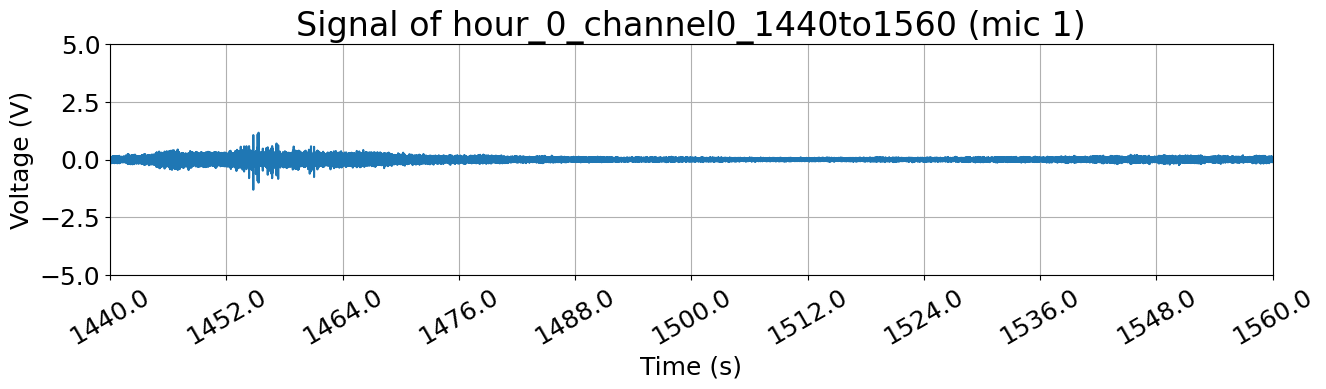

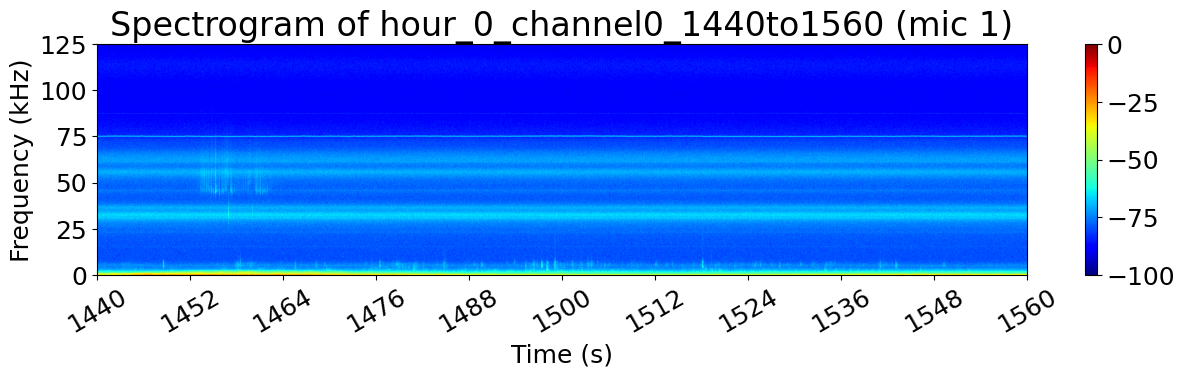

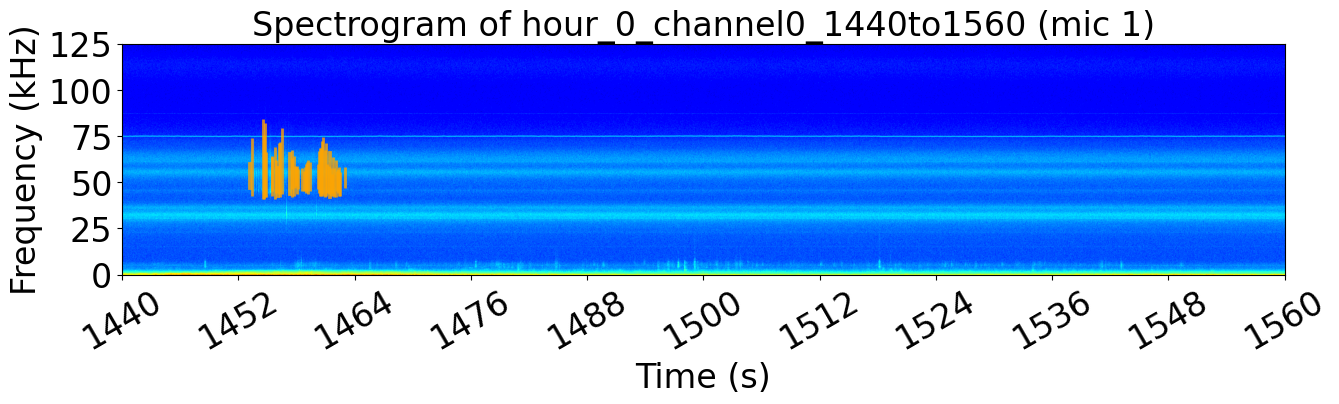

Generating detections from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1440to1560/hour_0_channel2_1440to1560.WAV


100%|██████████| 4/4 [00:27<00:00,  6.97s/it]


Median LF frequency in File: nan
Median HF frequency in File: 47040.0
Plotting data from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1440to1560/hour_0_channel2_1440to1560.WAV


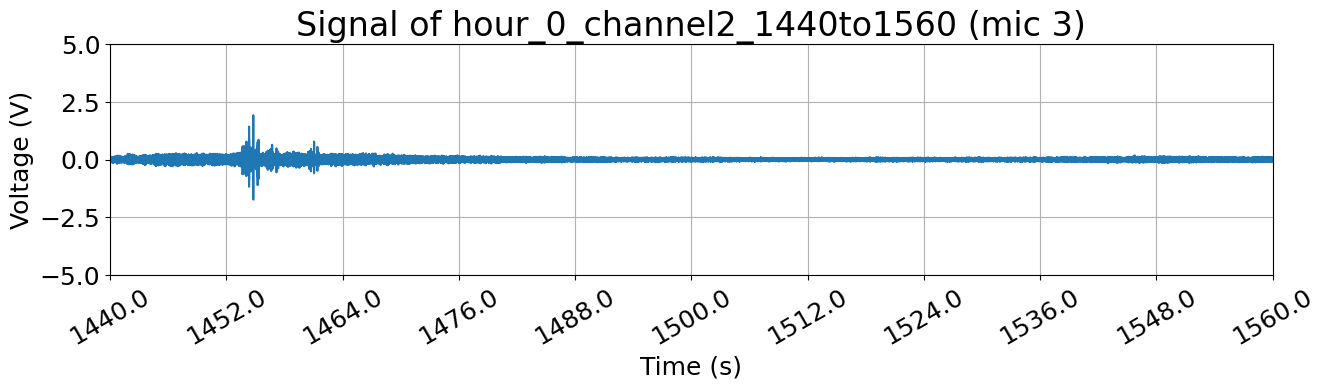

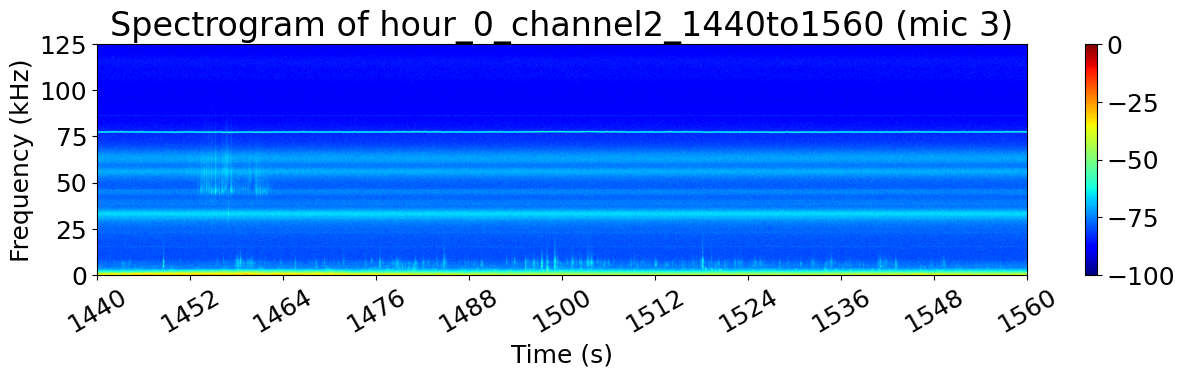

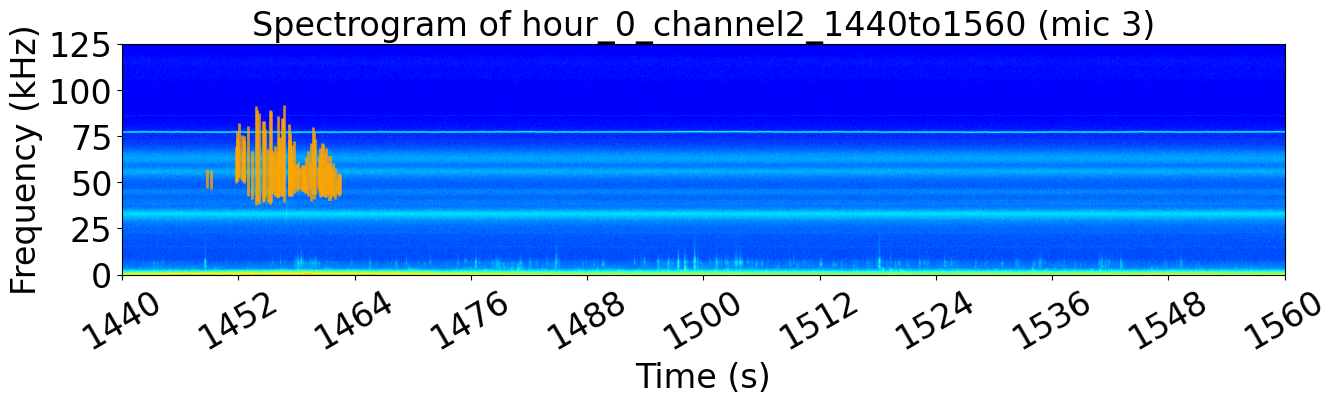

Generating detections from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1440to1560/hour_0_channel3_1440to1560.WAV


100%|██████████| 4/4 [00:28<00:00,  7.17s/it]


Median LF frequency in File: nan
Median HF frequency in File: 47040.0
Plotting data from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1440to1560/hour_0_channel3_1440to1560.WAV


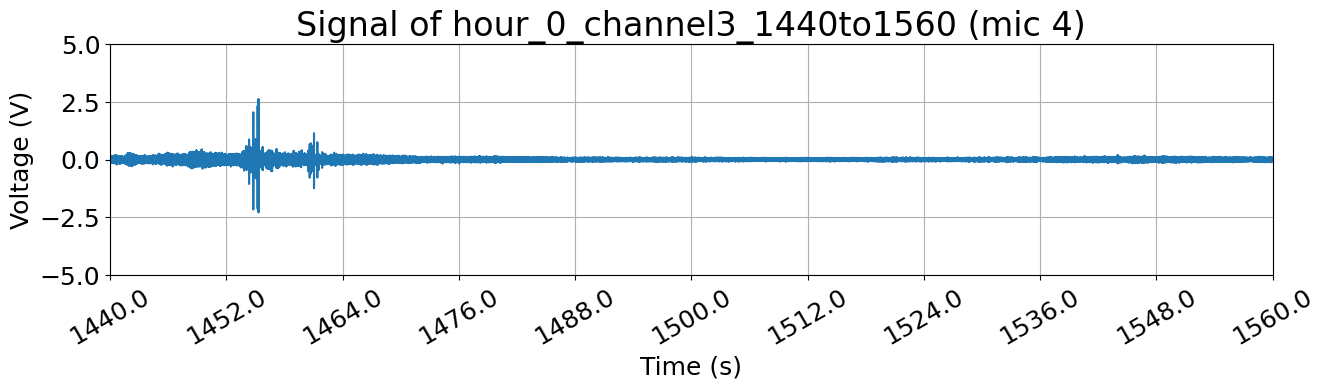

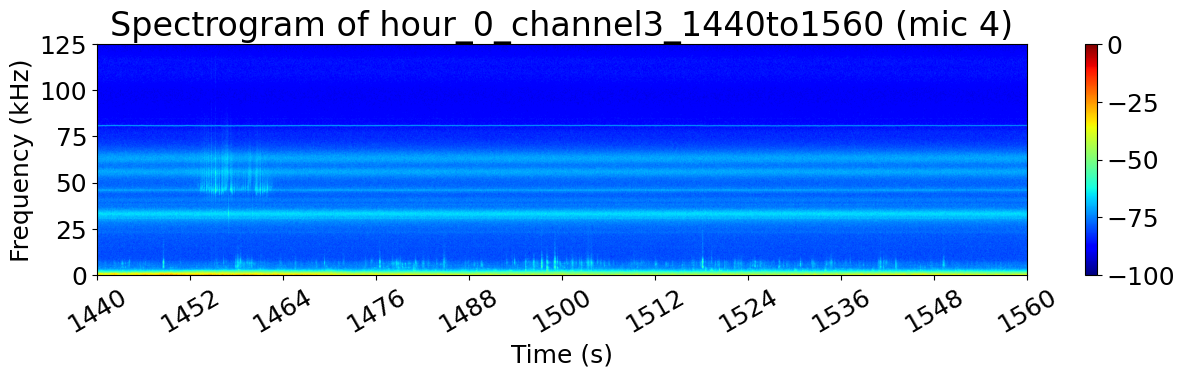

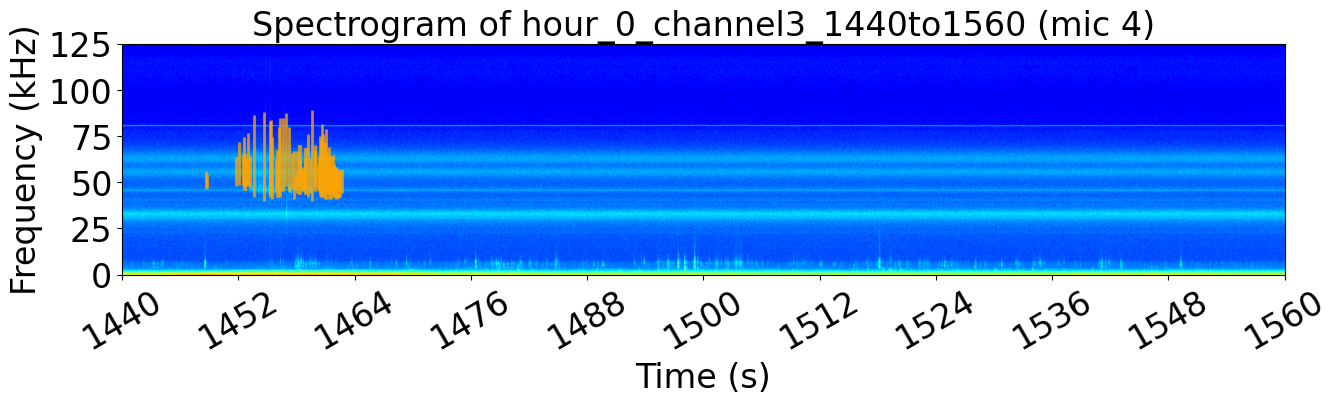

Generating detections from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1440to1560/hour_0_channel4_1440to1560.WAV


100%|██████████| 4/4 [00:28<00:00,  7.07s/it]


Median LF frequency in File: nan
Median HF frequency in File: 47040.0
Plotting data from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1440to1560/hour_0_channel4_1440to1560.WAV


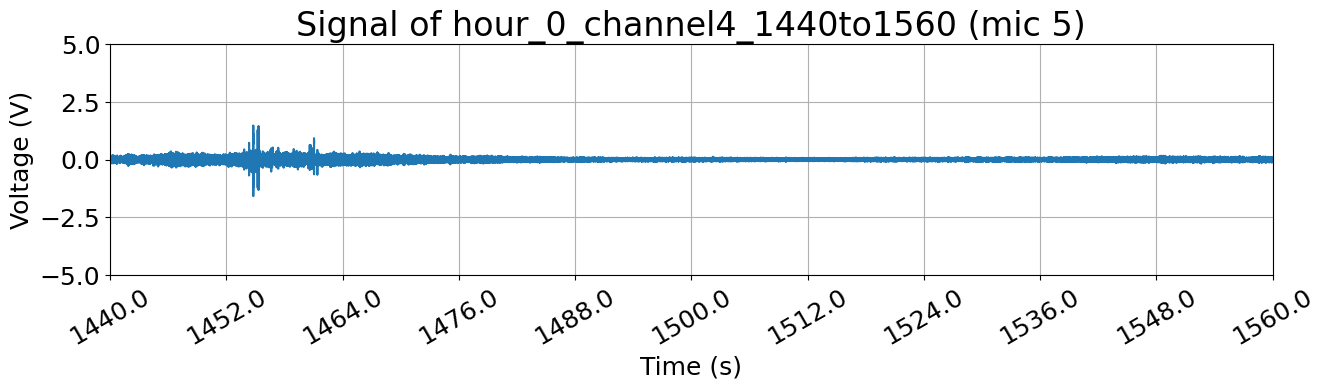

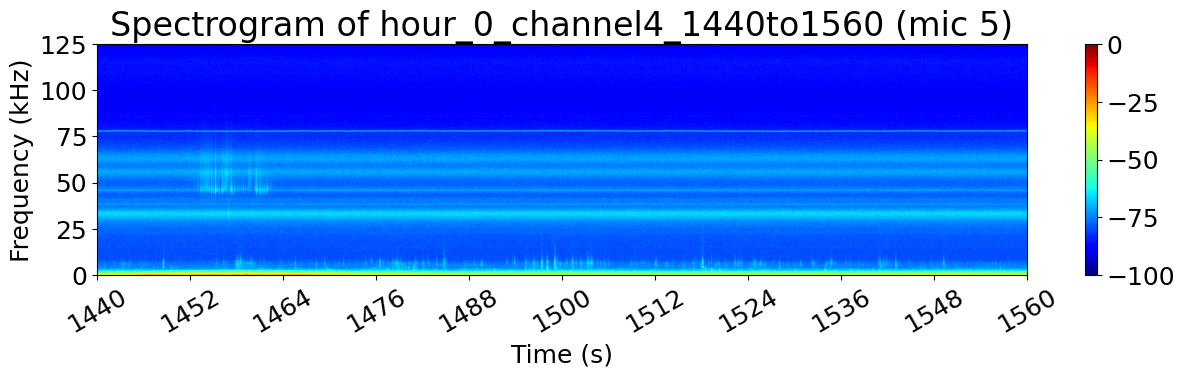

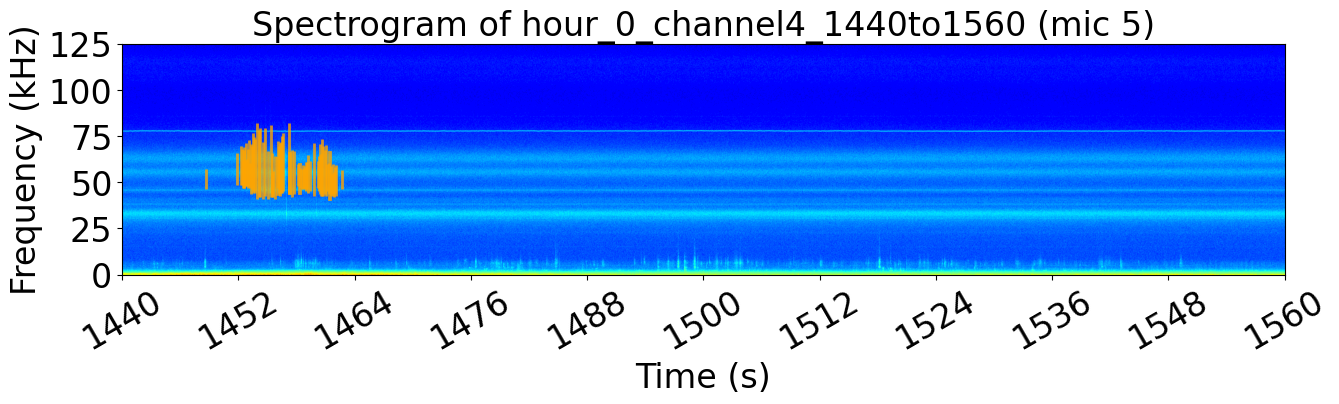

Generating detections from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1440to1560/hour_0_channel5_1440to1560.WAV


100%|██████████| 4/4 [00:29<00:00,  7.40s/it]


Median LF frequency in File: nan
Median HF frequency in File: 47040.0
Plotting data from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1440to1560/hour_0_channel5_1440to1560.WAV


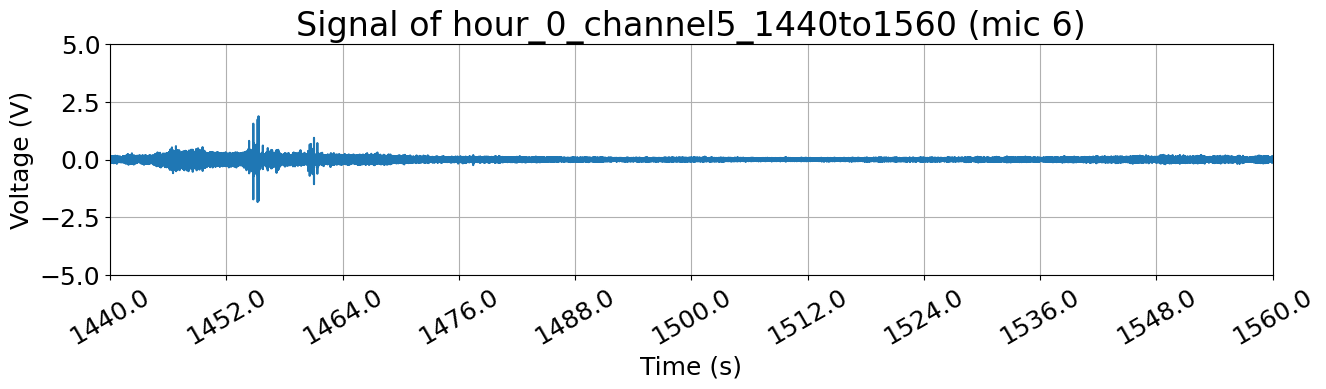

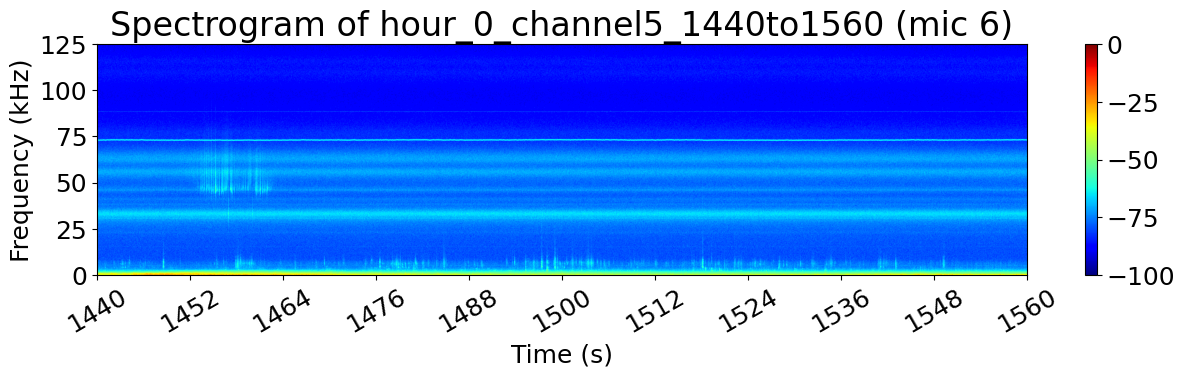

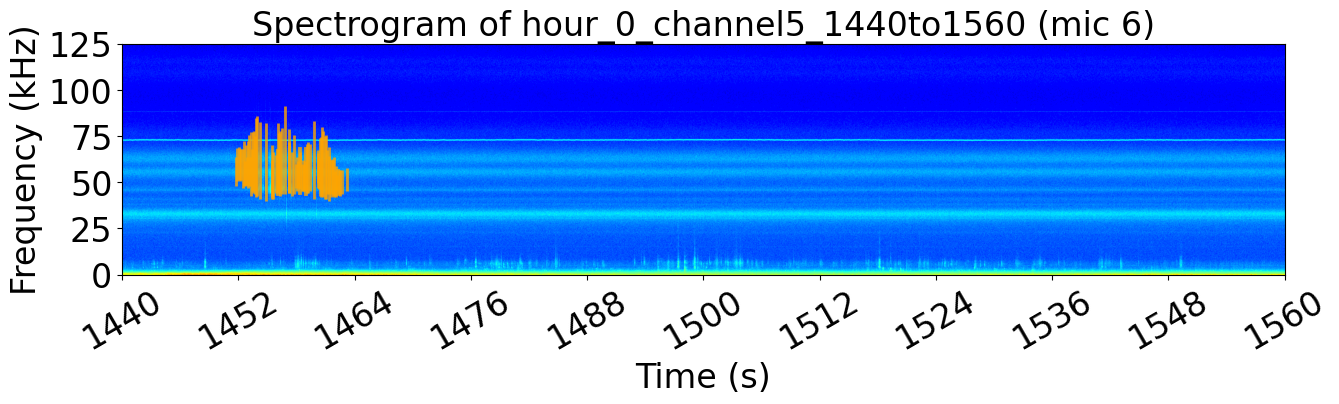

Generating detections from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1440to1560/hour_0_channel6_1440to1560.WAV


100%|██████████| 4/4 [00:28<00:00,  7.24s/it]


Median LF frequency in File: nan
Median HF frequency in File: 47040.0
Plotting data from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1440to1560/hour_0_channel6_1440to1560.WAV


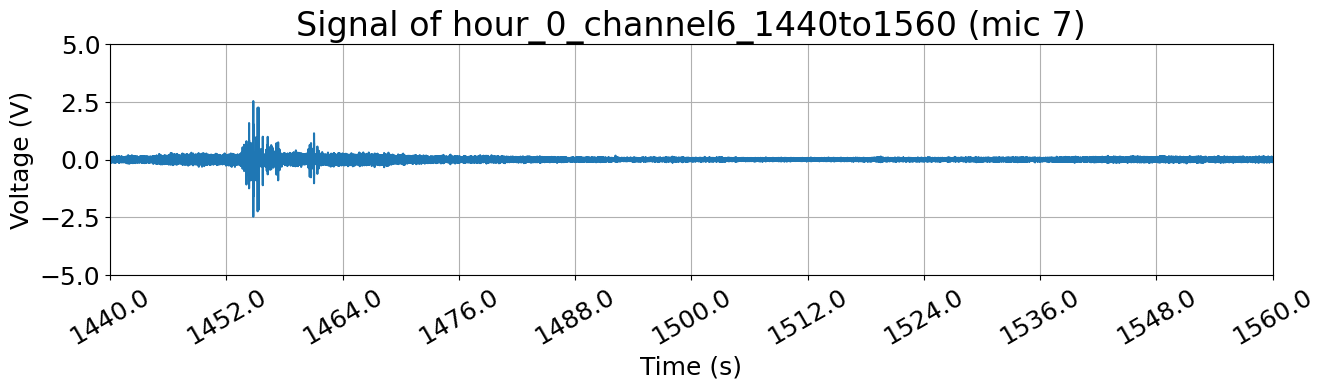

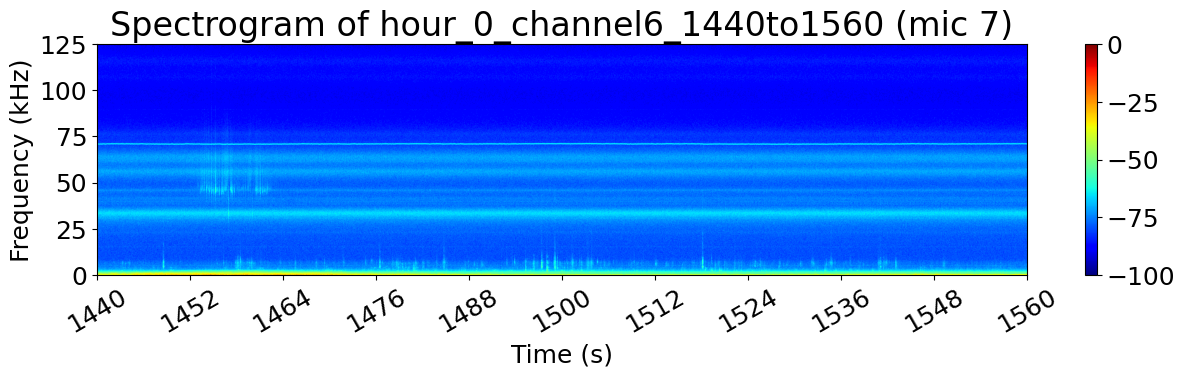

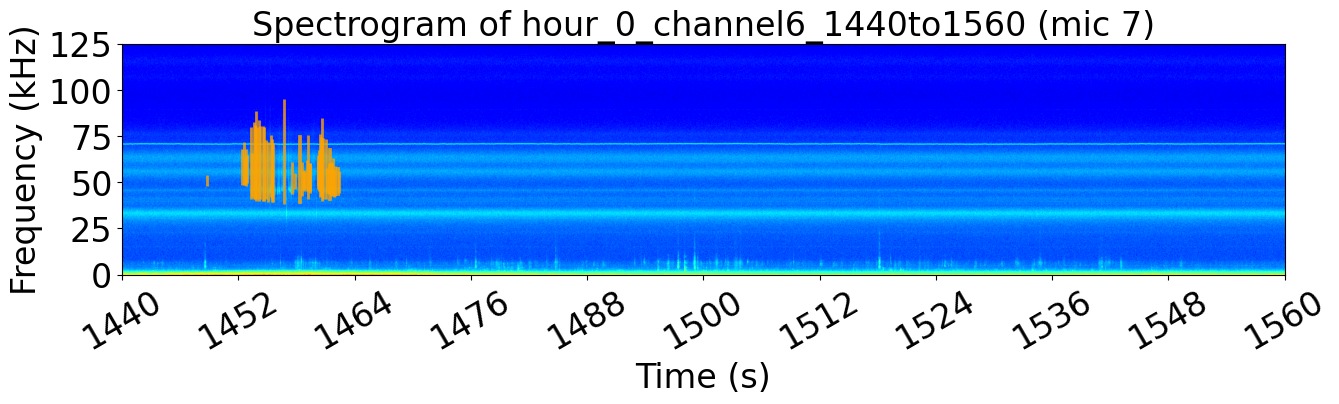

Generating detections from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1440to1560/hour_0_channel7_1440to1560.WAV


100%|██████████| 4/4 [00:29<00:00,  7.34s/it]


Median LF frequency in File: nan
Median HF frequency in File: 47040.0
Plotting data from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1440to1560/hour_0_channel7_1440to1560.WAV


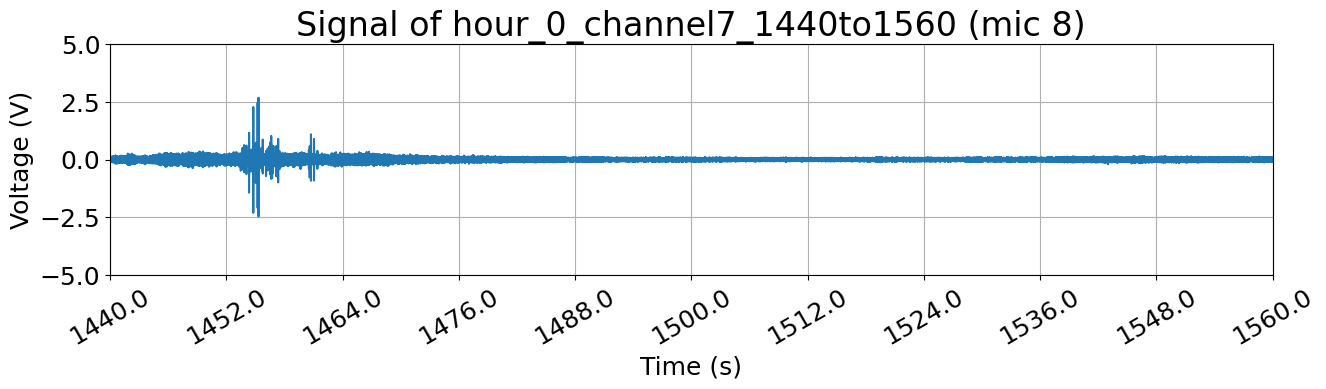

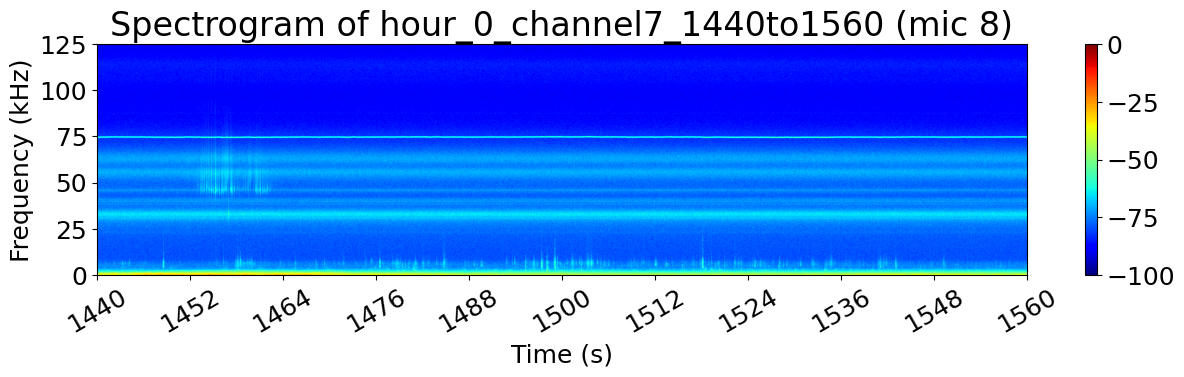

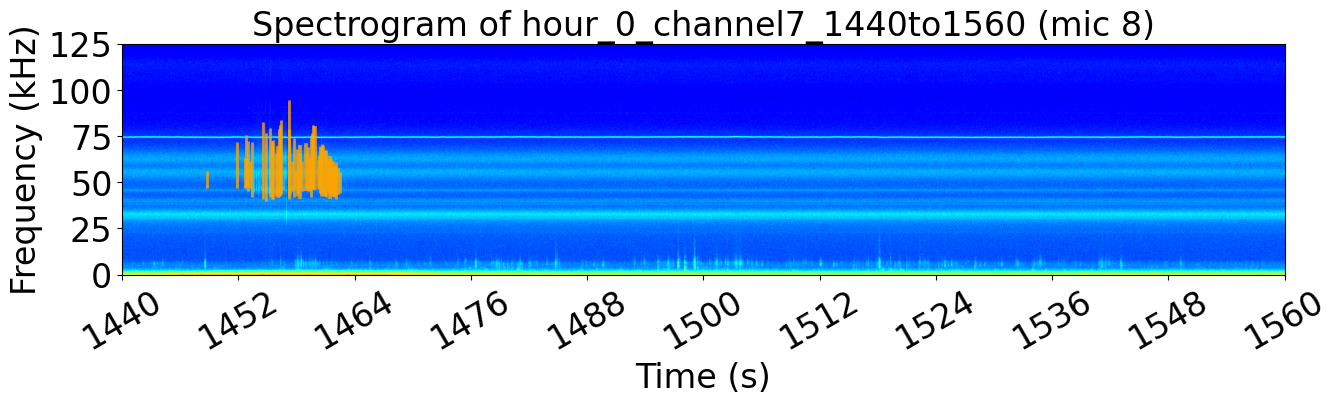

In [9]:
%matplotlib inline 

channel_dets = pd.DataFrame()
num_channels = 8
offset = 1440
duration_in_secs = 120
write_dir = Path(f'/Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/{filepath.stem}_{int(offset)}to{int(offset+duration_in_secs)}')

for selected_channel in np.arange(0, num_channels).astype(int):
    if selected_channel!=1:
        write_file = write_dir / f'{filepath.stem}_channel{selected_channel}_{int(offset)}to{int(offset+duration_in_secs)}.WAV'
        cfg['output_dir'] = write_dir
        cfg['input_audio'] = Path(write_file)
        dets = run_pipeline_on_file(write_file, cfg)
        
        recorded_audio = sf.SoundFile(write_file)
        audio_seg = recorded_audio.read(int(fs*duration_in_secs))

        print(f'Plotting data from {write_file}')
        vmax = 0
        vmin = -100

        audio_features = dict()
        audio_features['figsize'] = (15, 3)
        audio_features['file_path'] = write_file
        audio_features['audio_seg'] = audio_seg
        audio_features['sample_rate'] = fs
        audio_features['start'] = offset
        audio_features['duration'] = duration_in_secs

        spec_features = dict()
        spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = vmin
        spec_features['vmax'] = vmax

        audio_features['plot_title'] = f"{audio_features['file_path'].stem} (mic {selected_channel+1})"
        plot_audio_seg_signal(audio_features)
        plot_audio_seg_spec(audio_features, spec_features)
        plot_dets = dets.copy()
        plot_dets['start_time'] += offset
        plot_dets['end_time'] += offset
        channel_dets = pd.concat([channel_dets, plot_dets])
        plot_colored_dets_over_audio(audio_features, spec_features, plot_dets)

Plotting data from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1440to1560/hour_0_channel7_1440to1560.WAV
Plotting data from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1440to1560/hour_0_channel7_1440to1560.WAV
Time delay (in samples): 2193
Time delay (in seconds): 0.008772
Time delay (in samples): 1926
Time delay (in seconds): 0.007704
Time delay (in samples): 725
Time delay (in seconds): 0.0029
Time delay (in samples): 1366
Time delay (in seconds): 0.005464
Time delay (in samples): 656
Time delay (in seconds): 0.002624
Time delay (in samples): 1749
Time delay (in seconds): 0.006996
Time delay (in samples): 1467
Time delay (in seconds): 0.005868
Time delay (in samples): 1242
Time delay (in seconds): 0.004968
Time delay (in samples): 991
Time delay (in seconds): 0.003964
Time delay (in samples): -221
Time delay (in seconds): -0.000884
Time delay (in samples): 415
Time delay (in seconds): 0.00166
Time delay (in samples

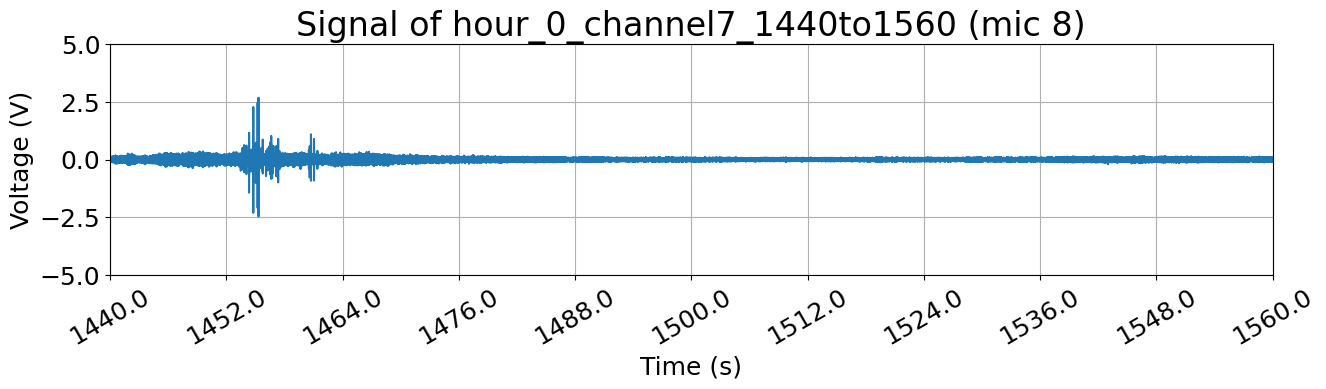

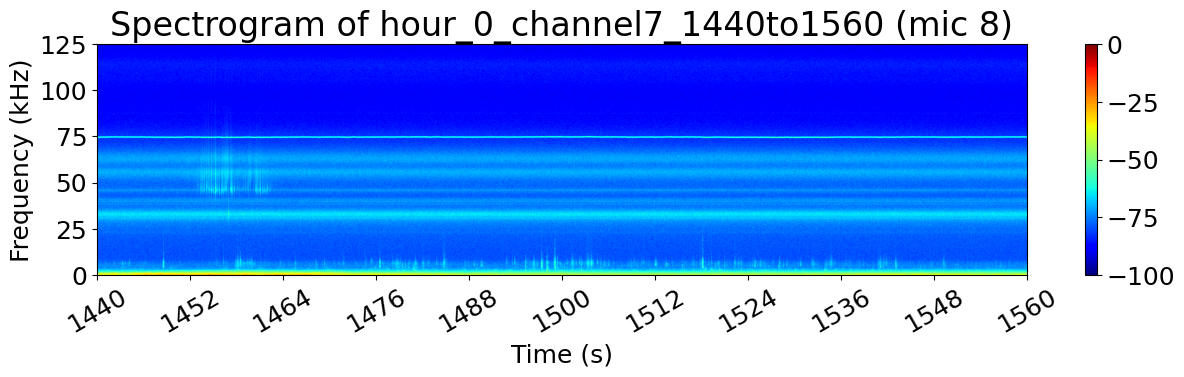

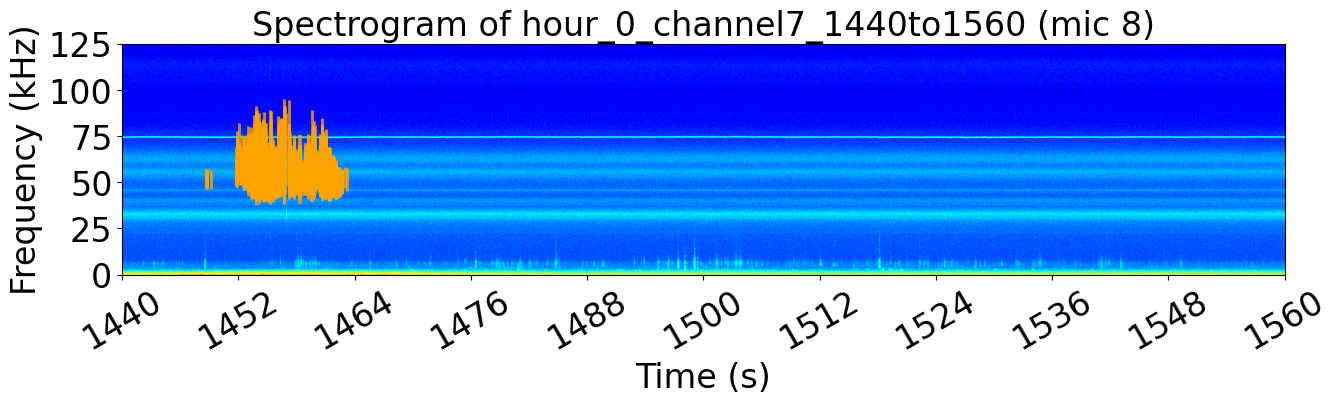

In [10]:
selected_channel = 7
write_file = write_dir / f'{filepath.stem}_channel{selected_channel}_{int(offset)}to{int(offset+duration_in_secs)}.WAV'
    
cfg['output_dir'] = write_dir
cfg['input_audio'] = Path(write_file)

recorded_audio = sf.SoundFile(write_file)
audio_seg = recorded_audio.read(int(fs*duration_in_secs))

print(f'Plotting data from {write_file}')
vmax = 0
vmin = -100

audio_features = dict()
audio_features['figsize'] = (15, 3)
audio_features['file_path'] = write_file
audio_features['audio_seg'] = audio_seg
audio_features['sample_rate'] = fs
audio_features['start'] = offset
audio_features['duration'] = duration_in_secs

spec_features = dict()
spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = vmin
spec_features['vmax'] = vmax

audio_features['plot_title'] = f"{audio_features['file_path'].stem} (mic {selected_channel+1})"
plot_audio_seg_signal(audio_features)
plot_audio_seg_spec(audio_features, spec_features)
plot_colored_dets_over_audio(audio_features, spec_features, channel_dets)

In [11]:
channel_dets = channel_dets.sort_values(by='start_time').copy()
channel_dets.reset_index(drop=True, inplace=True)
channel_dets

,KMEANS_CLASSES,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
0,HF,48000.0,0.068571,1448.6975,1448.7026,46093.0,56984.0,Pipistrellus pipistrellus,0.548,0.575,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
1,HF,54720.0,1.593416,1448.7005,1448.7067,46093.0,55914.0,Pipistrellus pipistrellus,0.535,0.565,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
2,HF,54720.0,0.356942,1448.7845,1448.7892,46953.0,57160.0,Pipistrellus pipistrellus,0.507,0.543,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
3,HF,48000.0,0.412240,1448.7865,1448.7918,46953.0,55979.0,Pipistrellus pipistrellus,0.596,0.608,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
4,HF,48000.0,0.799621,1448.7865,1448.7921,47812.0,53619.0,Pipistrellus pipistrellus,0.531,0.601,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,HF,48960.0,7.334427,1462.6615,1462.6661,44375.0,57368.0,Pipistrellus pipistrellus,0.454,0.560,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
434,HF,48960.0,6.469781,1462.6615,1462.6661,43515.0,56861.0,Pipistrellus pipistrellus,0.375,0.546,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
435,HF,48960.0,4.529781,1462.6645,1462.6694,46093.0,56495.0,Pipistrellus pipistrellus,0.576,0.602,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
436,HF,53760.0,0.276119,1463.0075,1463.0117,46953.0,58192.0,Pipistrellus pipistrellus,0.401,0.503,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...


In [12]:
def remove_close_times(df, time_column, threshold = 0.01):
    # Sort DataFrame by the time column
    df_sorted = df.sort_values(by=time_column).reset_index(drop=True)
    
    # Create a list to store the indices of the rows to keep
    filtered_indices = [0]  # Always keep the first row after sorting
    
    # Iterate through the sorted DataFrame, comparing each time to the previous kept time
    for i in range(1, len(df_sorted)):
        # Check if the difference between consecutive times is greater than or equal to the threshold
        if (df_sorted.loc[i, time_column] - df_sorted.loc[filtered_indices[-1], time_column]) >= threshold:
            filtered_indices.append(i)  # Keep the row if it meets the threshold
    
    # Return a DataFrame with only the filtered rows
    return df_sorted.loc[filtered_indices].reset_index(drop=True)

In [13]:
filtered_df = remove_close_times(channel_dets, 'start_time')
removed_overlaps = remove_close_times(filtered_df, 'end_time')
removed_overlaps

,KMEANS_CLASSES,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
0,HF,48000.0,0.068571,1448.6975,1448.7026,46093.0,56984.0,Pipistrellus pipistrellus,0.548,0.575,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
1,HF,54720.0,0.356942,1448.7845,1448.7892,46953.0,57160.0,Pipistrellus pipistrellus,0.507,0.543,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
2,HF,52800.0,1.259528,1449.1555,1449.1599,46093.0,56543.0,Pipistrellus pipistrellus,0.478,0.505,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
3,HF,56640.0,3.075944,1451.7465,1451.7495,49531.0,69124.0,Myotis alcathoe,0.338,0.505,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
4,HF,56640.0,5.651969,1451.8055,1451.8087,50390.0,74128.0,Myotis alcathoe,0.407,0.568,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,HF,47040.0,9.455383,1462.3895,1462.3942,43515.0,56780.0,Pipistrellus pipistrellus,0.524,0.639,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
101,HF,47040.0,8.727689,1462.4765,1462.4814,42656.0,56720.0,Pipistrellus pipistrellus,0.447,0.596,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
102,HF,48960.0,7.334427,1462.6615,1462.6661,44375.0,57368.0,Pipistrellus pipistrellus,0.454,0.560,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
103,HF,53760.0,0.276119,1463.0075,1463.0117,46953.0,58192.0,Pipistrellus pipistrellus,0.401,0.503,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...


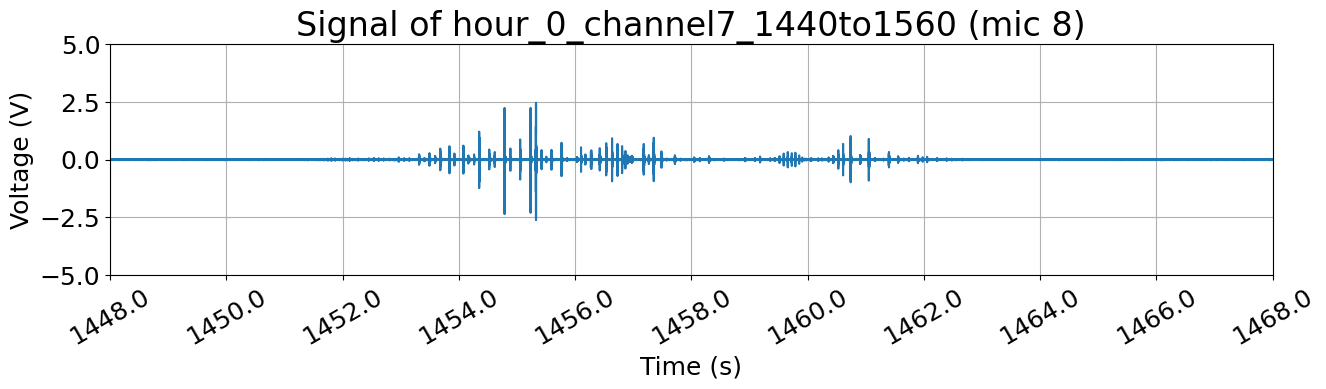

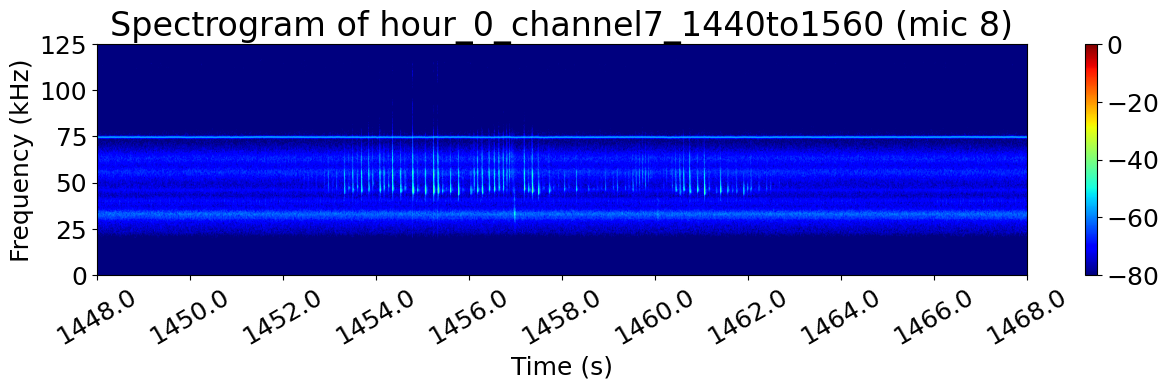

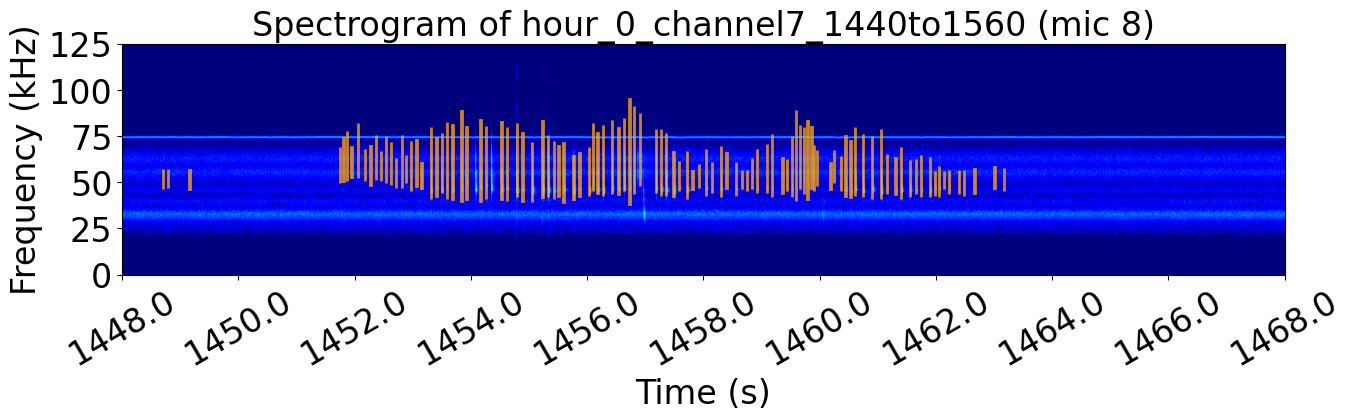

In [267]:
%matplotlib inline

selected_channel = 7
write_file = write_dir / f'{filepath.stem}_channel{selected_channel}_{int(offset)}to{int(offset+duration_in_secs)}.WAV'
    
cfg['output_dir'] = write_dir
cfg['input_audio'] = Path(write_file)

recorded_audio = sf.SoundFile(write_file)
start = 8
length = 20
recorded_audio.seek(int(fs*start))
audio_seg = recorded_audio.read(int(fs*length))
highpassed_audio_seg = highpass_audio_signal(audio_seg, fs, 20000)

print(f'Plotting data from {write_file}')
vmax = 0
vmin = -80

audio_features = dict()
audio_features['figsize'] = (15, 3)
audio_features['file_path'] = write_file
audio_features['audio_seg'] = highpassed_audio_seg
audio_features['sample_rate'] = fs
audio_features['start'] = offset + start
audio_features['duration'] = length

spec_features = dict()
spec_features['NFFT'] = 512 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = vmin
spec_features['vmax'] = vmax

audio_features['plot_title'] = f"{audio_features['file_path'].stem} (mic {selected_channel+1})"
plot_audio_seg_signal(audio_features)
plot_audio_seg_spec(audio_features, spec_features)
plot_dets = removed_overlaps.loc[(removed_overlaps['start_time']>=(offset+start))&(removed_overlaps['end_time']<=(offset+start+length))]
plot_colored_dets_over_audio(audio_features, spec_features, plot_dets)

In [268]:
plot_dets

,KMEANS_CLASSES,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
0,HF,48000.0,0.068571,1448.6975,1448.7026,46093.0,56984.0,Pipistrellus pipistrellus,0.548,0.575,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
1,HF,54720.0,0.356942,1448.7845,1448.7892,46953.0,57160.0,Pipistrellus pipistrellus,0.507,0.543,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
2,HF,52800.0,1.259528,1449.1555,1449.1599,46093.0,56543.0,Pipistrellus pipistrellus,0.478,0.505,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
3,HF,56640.0,3.075944,1451.7465,1451.7495,49531.0,69124.0,Myotis alcathoe,0.338,0.505,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
4,HF,56640.0,5.651969,1451.8055,1451.8087,50390.0,74128.0,Myotis alcathoe,0.407,0.568,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,HF,47040.0,9.455383,1462.3895,1462.3942,43515.0,56780.0,Pipistrellus pipistrellus,0.524,0.639,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
101,HF,47040.0,8.727689,1462.4765,1462.4814,42656.0,56720.0,Pipistrellus pipistrellus,0.447,0.596,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
102,HF,48960.0,7.334427,1462.6615,1462.6661,44375.0,57368.0,Pipistrellus pipistrellus,0.454,0.560,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
103,HF,53760.0,0.276119,1463.0075,1463.0117,46953.0,58192.0,Pipistrellus pipistrellus,0.401,0.503,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...


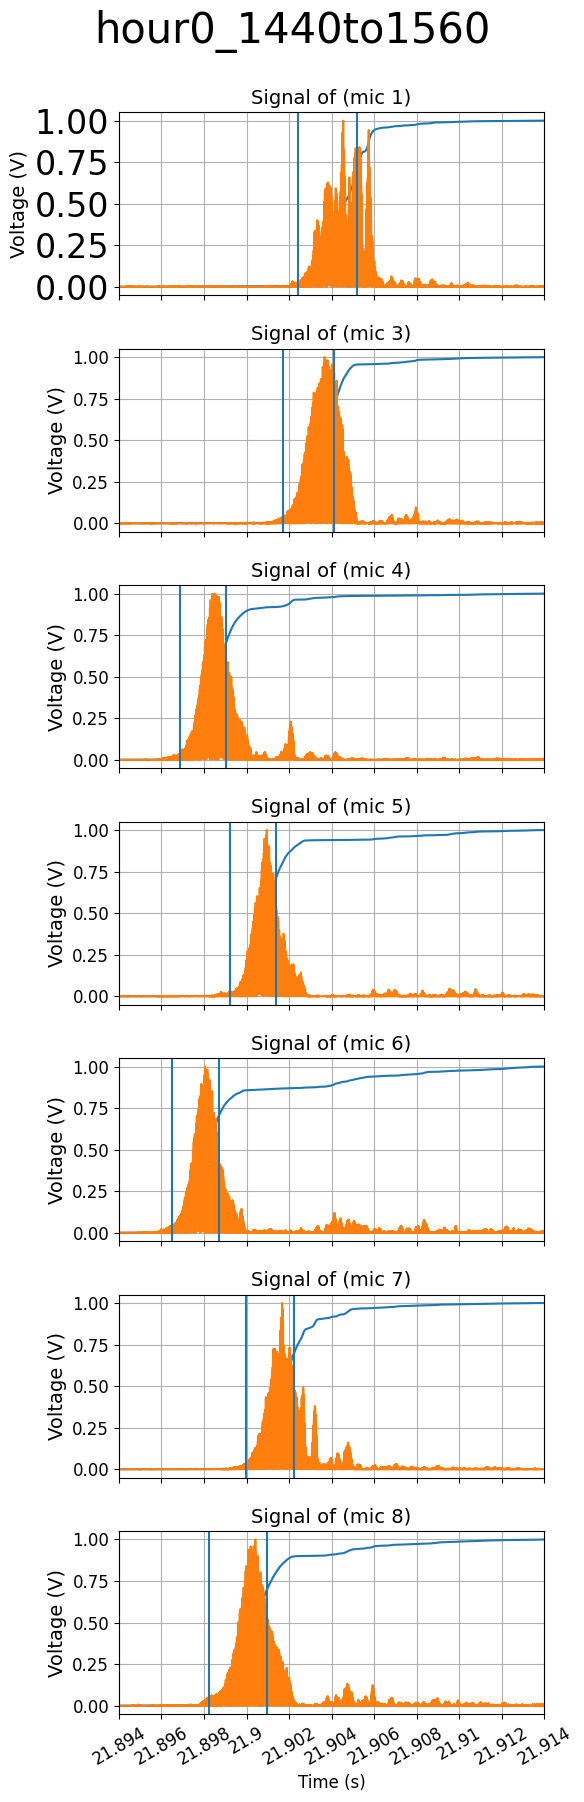

In [269]:
channel_num = 0
plt.figure(figsize=(6, 18))
plt.suptitle(f'hour0_{int(offset)}to{int(offset+duration_in_secs)}', y=1.0, fontsize=30)
for selected_channel in (np.arange(0, num_channels).astype(int)):
    if selected_channel!=1:
        write_file = write_dir / f'{filepath.stem}_channel{selected_channel}_{int(offset)}to{int(offset+duration_in_secs)}.WAV'
        
        det = plot_dets.iloc[-10]
        channel_num+=1
        start = det['start_time'] - offset - 0.001
        length = 0.02
        
        recorded_audio = sf.SoundFile(write_file)
        recorded_audio.seek(int(fs*start))
        audio_seg = recorded_audio.read(int(fs*length))
        bandpassed_audio_seg = bandpass_audio_signal(audio_seg, fs, det['low_freq'], det['high_freq'])

        # print(f'Plotting data from {write_file}')
        vmax = 0
        vmin = -100

        spec_features = dict()
        spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = vmin
        spec_features['vmax'] = vmax

        plt.subplot(7, 1, channel_num)
        plt.rcParams.update({'font.size': 12})
        plt.title(f"Signal of (mic {selected_channel+1})", fontsize=14)
        # plt.plot((bandpassed_audio_seg/np.max(bandpassed_audio_seg)))
        
        p_energy_cumsum = np.cumsum((bandpassed_audio_seg)**2)/np.sum(bandpassed_audio_seg**2)
        diff_penergy = (p_energy_cumsum[1:] - p_energy_cumsum[:-1])/np.max(p_energy_cumsum[1:] - p_energy_cumsum[:-1])
        cumsum_start = np.where(p_energy_cumsum>0.01)[0][0]
        cumsum_end = np.where((p_energy_cumsum>0.7)&(np.hstack([diff_penergy, 0])<0.1))[0][0]
        plt.plot(p_energy_cumsum)
        plt.plot(diff_penergy)
        plt.axvline(x=cumsum_start)
        plt.axvline(x=cumsum_end)
        plot_xtype = 'float'
        plt.xlim(0, length*fs)
        if selected_channel == 1:
            plt.ylim(-0.001, 0.001)
        plt.grid(which='both')
        plt.ylabel("Voltage (V)", fontsize=14)
        plt.xticks(ticks=np.linspace(0, length*fs, 11), labels=['']*11, rotation=30)
        
plt.xticks(ticks=np.linspace(0, length*fs, 11), labels=np.round(np.linspace(start, start+length, 11, dtype=plot_xtype), 3), rotation=30)
plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

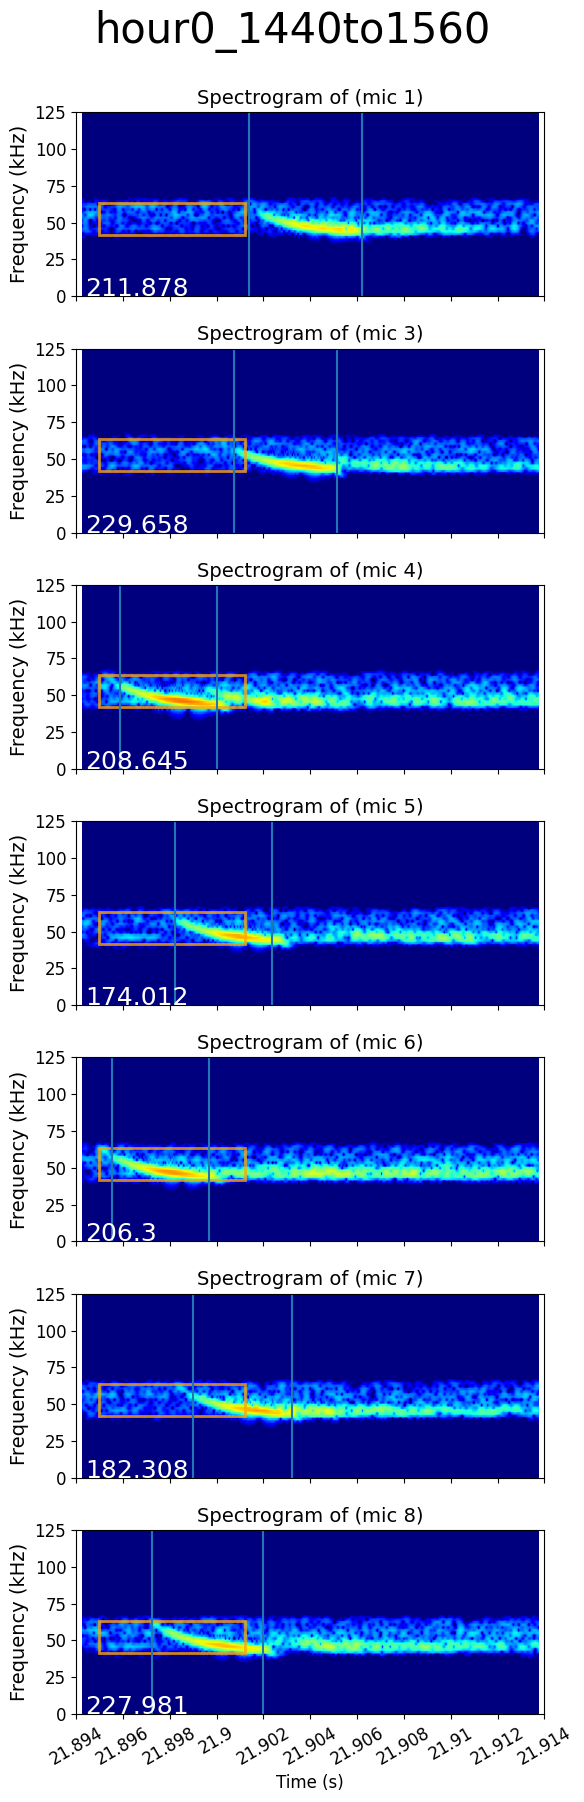

In [270]:
%matplotlib inline

calls = []
channel_num = 0
plt.figure(figsize=(6, 18))
plt.suptitle(f'hour0_{int(offset)}to{int(offset+duration_in_secs)}', y=1.0, fontsize=30)
disc_energies = []
for selected_channel in (np.arange(0, num_channels).astype(int)):
    if selected_channel!=1:
        write_file = write_dir / f'{filepath.stem}_channel{selected_channel}_{int(offset)}to{int(offset+duration_in_secs)}.WAV'
        
        det = plot_dets.iloc[-10]
        channel_num+=1
        start = det['start_time'] - offset - 0.001
        length = 0.02
        
        recorded_audio = sf.SoundFile(write_file)
        recorded_audio.seek(int(fs*start))
        audio_seg = recorded_audio.read(int(fs*length))
        highpassed_audio_seg = highpass_audio_signal(audio_seg, fs, 30000)
        bandpassed_audio_seg = bandpass_audio_signal(audio_seg, fs, det['low_freq'], det['high_freq'])
        calls += [highpassed_audio_seg]

        # print(f'Plotting data from {write_file}')
        vmax = 0
        vmin = -80

        audio_features = dict()
        audio_features['file_path'] = write_file
        audio_features['audio_seg'] = highpassed_audio_seg
        audio_features['sample_rate'] = fs
        audio_features['start'] = start
        audio_features['duration'] = length

        spec_features = dict()
        spec_features['NFFT'] = 132 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = vmin
        spec_features['vmax'] = vmax

        audio_features['plot_title'] = f"(mic {selected_channel+1})"

        plt.subplot(7, 1, channel_num)
        plt.rcParams.update({'font.size': 12})
        plt.title(f"Spectrogram of {audio_features['plot_title']}", fontsize=14)
        plt.specgram(bandpassed_audio_seg+1e-6, NFFT=spec_features['NFFT'], cmap='jet', vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')

        p_energy_cumsum = np.cumsum((bandpassed_audio_seg)**2)/np.sum(bandpassed_audio_seg**2)
        diff_penergy = (p_energy_cumsum[1:] - p_energy_cumsum[:-1])/np.max(p_energy_cumsum[1:] - p_energy_cumsum[:-1])
        cumsum_start = np.where(p_energy_cumsum>0.01)[0][0]
        cumsum_end = np.where((p_energy_cumsum>0.7)&(np.hstack([diff_penergy, 0])<0.1))[0][0]
        # plt.plot(p_energy_cumsum)
        # plt.plot(diff_penergy)
        plt.axvline(x=(cumsum_start-int(fs*0.001))/2)
        plt.axvline(x=(cumsum_end+int(fs*0.001))/2)

        ax = plt.gca()
        rect = patches.Rectangle(((det['start_time'] - offset - start)*(fs/2), det['low_freq']/(fs/2)), 
                        (det['end_time'] - det['start_time'])*(fs/2), (det['high_freq'] - det['low_freq'])/(fs/2), 
                        linewidth=2, edgecolor=FREQ_COLORS[det['KMEANS_CLASSES']], facecolor='none', alpha=0.8)
        ax.add_patch(rect)
        plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
        disc_energy=np.sum((bandpassed_audio_seg/np.max(bandpassed_audio_seg))**2)
        disc_energies+=[disc_energy]
        plt.text(x=50,y=0,s=f'{round(disc_energy, 3)}',color='w',fontsize=18)
        plot_xtype = 'float'
        if (length > 60):
            plot_xtype = 'int'
        plt.ylabel("Frequency (kHz)", fontsize=14)
        plt.xticks(ticks=np.linspace(0, length*(fs/2), 11), labels=['']*11, rotation=30)
        plt.xlabel("")
        
plt.xticks(ticks=np.linspace(0, length*(fs/2), 11), labels=np.round(np.linspace(start, start+length, 11, dtype=plot_xtype), 3), rotation=30)
plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

In [271]:
C = 343 # m/s speed of sound in air
num_good_channels = num_channels - 1
num_nonref_channels = num_good_channels - 1
calls = np.array(calls)
calls

array([[-1.67375292e-06, -2.81947547e-03, -1.07082353e-02, ...,
         3.20724295e-03,  2.21677133e-03, -4.51773501e-05],
       [ 2.12226417e-06, -5.91532443e-03, -1.79892028e-03, ...,
        -3.18720208e-03, -6.23341450e-03,  1.61432005e-04],
       [-1.54116423e-05, -3.54572675e-04, -3.47870757e-03, ...,
        -2.09897316e-02, -1.43261796e-02,  3.82960752e-04],
       ...,
       [-8.31624505e-06, -6.97392301e-04,  5.65666768e-04, ...,
        -2.04280420e-02, -1.52776524e-02,  2.48525719e-04],
       [ 1.71249950e-05, -1.05992066e-02, -6.69248663e-03, ...,
         4.67351691e-03,  3.01769737e-03, -1.06757597e-04],
       [ 1.66030825e-06,  1.37036800e-03, -5.46031771e-03, ...,
        -5.06400971e-03, -4.56112719e-03,  3.23375867e-04]])

In [272]:
ref_mic_call = calls[np.argmax(np.array(disc_energies)),:]
nonref_mic_calls = calls
nonref_mic_calls

array([[-1.67375292e-06, -2.81947547e-03, -1.07082353e-02, ...,
         3.20724295e-03,  2.21677133e-03, -4.51773501e-05],
       [ 2.12226417e-06, -5.91532443e-03, -1.79892028e-03, ...,
        -3.18720208e-03, -6.23341450e-03,  1.61432005e-04],
       [-1.54116423e-05, -3.54572675e-04, -3.47870757e-03, ...,
        -2.09897316e-02, -1.43261796e-02,  3.82960752e-04],
       ...,
       [-8.31624505e-06, -6.97392301e-04,  5.65666768e-04, ...,
        -2.04280420e-02, -1.52776524e-02,  2.48525719e-04],
       [ 1.71249950e-05, -1.05992066e-02, -6.69248663e-03, ...,
         4.67351691e-03,  3.01769737e-03, -1.06757597e-04],
       [ 1.66030825e-06,  1.37036800e-03, -5.46031771e-03, ...,
        -5.06400971e-03, -4.56112719e-03,  3.23375867e-04]])

In [273]:
nonref_mic_calls.shape

(7, 5000)

In [274]:
ref_mic_call

array([ 2.12226417e-06, -5.91532443e-03, -1.79892028e-03, ...,
       -3.18720208e-03, -6.23341450e-03,  1.61432005e-04])

In [275]:
p_energy_cumsum = np.cumsum((ref_mic_call)**2)/np.sum(ref_mic_call**2)
diff_penergy = (p_energy_cumsum[1:] - p_energy_cumsum[:-1])/np.max(p_energy_cumsum[1:] - p_energy_cumsum[:-1])
cumsum_start = np.where(p_energy_cumsum>0.01)[0][0]
cumsum_end = np.where((p_energy_cumsum>0.7)&(np.hstack([diff_penergy, 0])<0.1))[0][0]

Text(0.5, 0, '')

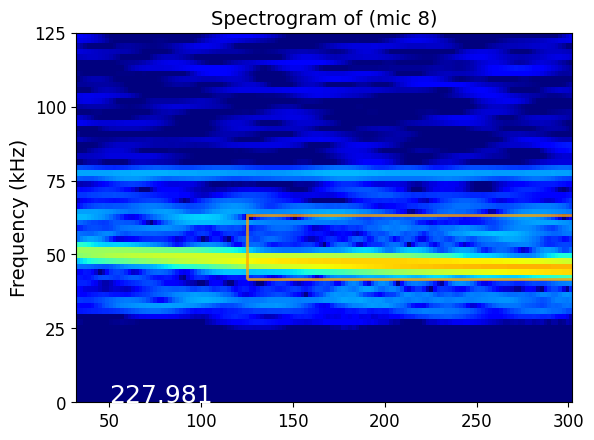

In [276]:
# plt.specgram(ref_mic_call[cumsum_start-int(fs*0.001):cumsum_end])
ref_mic_call_only = ref_mic_call[(cumsum_start):(cumsum_end)]
plt.title(f"Spectrogram of {audio_features['plot_title']}", fontsize=14)
plt.specgram(ref_mic_call_only, NFFT=spec_features['NFFT'], cmap='jet', vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
ax = plt.gca()
rect = patches.Rectangle(((det['start_time'] - offset - start)*(fs/2), det['low_freq']/(fs/2)), 
                (det['end_time'] - det['start_time'])*(fs/2), (det['high_freq'] - det['low_freq'])/(fs/2), 
                linewidth=2, edgecolor=FREQ_COLORS[det['KMEANS_CLASSES']], facecolor='none', alpha=0.8)
ax.add_patch(rect)
plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
disc_energy=np.sum((bandpassed_audio_seg/np.max(bandpassed_audio_seg))**2)
disc_energies+=[disc_energy]
plt.text(x=50,y=0,s=f'{round(disc_energy, 3)}',color='w',fontsize=18)
plot_xtype = 'float'
if (length > 60):
    plot_xtype = 'int'
plt.ylabel("Frequency (kHz)", fontsize=14)
# plt.xticks(ticks=np.linspace(0, length*(fs/2), 11), labels=['']*11, rotation=30)
plt.xlabel("")

In [277]:
%matplotlib inline

t_delay_wrt_selected_channel = []
for i in range(num_good_channels):
    signal1 = nonref_mic_calls[i]
    signal2 = ref_mic_call_only

    # Step 1: Cross-correlation of the two signals
    correlation = signal.correlate(signal1, signal2, mode='full')

    # Step 2: Get the lags for the correlation
    lags = signal.correlation_lags(len(signal1), len(signal2), mode='full')

    # Step 3: Find the index of the maximum correlation
    max_lag_index = np.argmax(correlation)

    # Step 4: Calculate the time delay corresponding to the max correlation
    time_delay = lags[max_lag_index]

    # Assuming the sampling rate is 500 Hz (replace with your actual rate)
    time_delay_in_seconds = time_delay / fs

    print(f"Time delay (in samples): {time_delay}")
    print(f"Time delay (in seconds): {time_delay_in_seconds}")

    t_delay_wrt_selected_channel += [time_delay_in_seconds]

In [278]:
t_delay_wrt_selected_channel

[0.00852, 0.007516, 0.002668, 0.005276, 0.002436, 0.005724, 0.004552]

In [279]:
t_delay_8_to_selected_channel = t_delay_wrt_selected_channel[-1]
(t_delay_wrt_selected_channel - t_delay_8_to_selected_channel)

array([ 0.003968,  0.002964, -0.001884,  0.000724, -0.002116,  0.001172,
        0.      ])

In [280]:
time_delay_mics_to_channel8 = (t_delay_wrt_selected_channel - t_delay_8_to_selected_channel)[:-1]
time_delay_mics_to_channel8

array([ 0.003968,  0.002964, -0.001884,  0.000724, -0.002116,  0.001172])

In [281]:
time_delay_mics_to_channel8 = np.array(time_delay_mics_to_channel8).reshape((1, num_nonref_channels))
time_delay_mics_to_channel8

array([[ 0.003968,  0.002964, -0.001884,  0.000724, -0.002116,  0.001172]])

In [282]:
d_mics_to_ref = time_delay_mics_to_channel8 * C
d_mics_to_ref

array([[ 1.361024,  1.016652, -0.646212,  0.248332, -0.725788,  0.401996]])

In [283]:
z_mag_ref_to_6 = 46.5625
z_mag_ref_to_1 = 35.5
x_mag_ref_to_1 = 17.7
y_mag_ref_to_6 = 21
y_mag_ref_to_1 = 37.5

A_locs_mat = np.array([[-x_mag_ref_to_1, y_mag_ref_to_1, -z_mag_ref_to_1],
                  [-x_mag_ref_to_1, y_mag_ref_to_1, 0],
                  [-x_mag_ref_to_1, -y_mag_ref_to_1, 0],
                  [-x_mag_ref_to_1, y_mag_ref_to_6, z_mag_ref_to_6],
                  [-x_mag_ref_to_1, -y_mag_ref_to_6, z_mag_ref_to_6],
                  [0, 0, -z_mag_ref_to_1]])

A_locs_mat = A_locs_mat[:,:]
A_locs_mat

array([[-17.7   ,  37.5   , -35.5   ],
       [-17.7   ,  37.5   ,   0.    ],
       [-17.7   , -37.5   ,   0.    ],
       [-17.7   ,  21.    ,  46.5625],
       [-17.7   , -21.    ,  46.5625],
       [  0.    ,   0.    , -35.5   ]])

In [284]:
A_mat = np.hstack(((0 - A_locs_mat), d_mics_to_ref[0,:].reshape((num_nonref_channels, 1))))

xm = A_locs_mat[:,0]
ym = A_locs_mat[:,1]
zm = A_locs_mat[:,2]

wm0 = (d_mics_to_ref[0,:]**2) - (xm**2) - (ym**2) - (zm**2)
wm0 = wm0.reshape((num_nonref_channels, 1))

A_pinv = np.linalg.pinv(A_mat)
source_vec = np.dot(A_pinv, wm0)
source_vec

array([[    70.47956289],
       [  -418.7110033 ],
       [   181.25686707],
       [-18942.35745905]])

In [320]:
fs = 250000
calls_for_tdoa = []
disc_energies = []
subset = plot_dets[:].copy()
subset = subset[subset['SNR']>20].reset_index(drop=True)
for det_num, det in subset.iterrows():
    for selected_channel in (np.arange(0, num_channels).astype(int)):
        if selected_channel!=1:
            start = det['start_time'] - offset - 0.001
            length = 0.02

            wav_file = write_dir / f'{filepath.stem}_channel{selected_channel}_{int(offset)}to{int(offset+duration_in_secs)}.WAV'
            
            mic_audio = sf.SoundFile(wav_file)
            mic_audio.seek(int(fs*start))
            mic_call = mic_audio.read(int(fs*length))
            highpassed_mic_call = highpass_audio_signal(mic_call, fs, 20000)
            bandpassed_audio_seg = bandpass_audio_signal(mic_call, fs, det['low_freq'], det['high_freq'])
            calls_for_tdoa += [highpassed_mic_call]
            disc_energy=np.sum(bandpassed_audio_seg**2)
            disc_energies+=[disc_energy]
            
calls_for_tdoa = np.array(calls_for_tdoa).reshape((len(subset), num_good_channels, int(fs*length)))
disc_energies = np.array(disc_energies).reshape((len(subset), num_good_channels))

In [321]:
t_delay_wrt_selected_channel = []
for det_num in range(calls_for_tdoa.shape[0]):
    non_ref_calls_of_det = calls_for_tdoa[det_num]
    ref_call_of_det = calls_for_tdoa[det_num, np.argmax(disc_energies[det_num]),:]

    p_energy_cumsum = np.cumsum((ref_call_of_det)**2)/np.sum(ref_call_of_det**2)
    diff_penergy = (p_energy_cumsum[1:] - p_energy_cumsum[:-1])/np.max(p_energy_cumsum[1:] - p_energy_cumsum[:-1])
    cumsum_start = np.where(p_energy_cumsum>0.01)[0][0]
    cumsum_end = np.where((p_energy_cumsum>0.7)&(np.hstack([diff_penergy, 0])<0.1))[0][0]
    ref_mic_call_only = ref_call_of_det[cumsum_start:cumsum_end]

    for non_ref_call_i in range(non_ref_calls_of_det.shape[0]):
        nonref_mic_call = non_ref_calls_of_det[non_ref_call_i]
        signal1 = nonref_mic_call
        signal2 = ref_mic_call_only

        # Step 1: Cross-correlation of the two signals
        correlation = signal.correlate(signal1, signal2, mode='full')
        # Step 2: Get the lags for the correlation
        lags = signal.correlation_lags(len(signal1), len(signal2), mode='full')
        # Step 3: Find the index of the maximum correlation
        max_lag_index = np.argmax(correlation)
        # Step 4: Calculate the time delay corresponding to the max correlation
        time_delay = lags[max_lag_index]
        # Assuming the sampling rate is 500 Hz (replace with your actual rate)
        time_delay_in_seconds = time_delay / fs

        # print(f"Time delay (in samples): {time_delay}")
        # print(f"Time delay (in seconds): {time_delay_in_seconds}")
        t_delay_wrt_selected_channel += [time_delay_in_seconds]

In [322]:
t_delay_wrt_selected_channel = np.array(t_delay_wrt_selected_channel).reshape((len(subset), num_good_channels))
t_delay_8_to_selected_channel = t_delay_wrt_selected_channel[:,-1]
time_delay_mics_to_channel8 = (t_delay_wrt_selected_channel - t_delay_wrt_selected_channel[:,-1].reshape((len(subset), 1)))[:,:-1]
d_mics_to_ref = time_delay_mics_to_channel8 * C
d_mics_to_ref.shape

(32, 6)

In [323]:
bucket = np.empty((4, 0))
for i in range(d_mics_to_ref.shape[0]):
    A_mat = np.hstack(((0 - A_locs_mat), d_mics_to_ref[i,:].reshape((num_nonref_channels, 1))))

    xm = A_locs_mat[:,0]
    ym = A_locs_mat[:,1]
    zm = A_locs_mat[:,2]

    wm0 = (d_mics_to_ref[i,:]**2) - (xm**2) - (ym**2) - (zm**2)
    wm0 = wm0.reshape((num_nonref_channels, 1))

    A_pinv = np.linalg.pinv(A_mat)
    source_vec = np.dot(A_pinv, wm0)

    bucket = np.hstack([bucket, source_vec])

In [324]:
# bad_indices = ((np.isclose(bucket[0,:], 0, atol=20))|(np.isclose(bucket[1,:], 0, atol=20))|(np.isclose(bucket[2,:], 0, atol=20))|(np.isclose(bucket[3,:], 0, atol=20)))
bad_indices = np.abs(bucket[3,:])<=3000
good_indices = ~bad_indices
cleaned_bucket = bucket[:,good_indices]
good_dets = subset[good_indices]
bad_bucket = bucket[:,bad_indices]
bad_dets = subset[bad_indices]

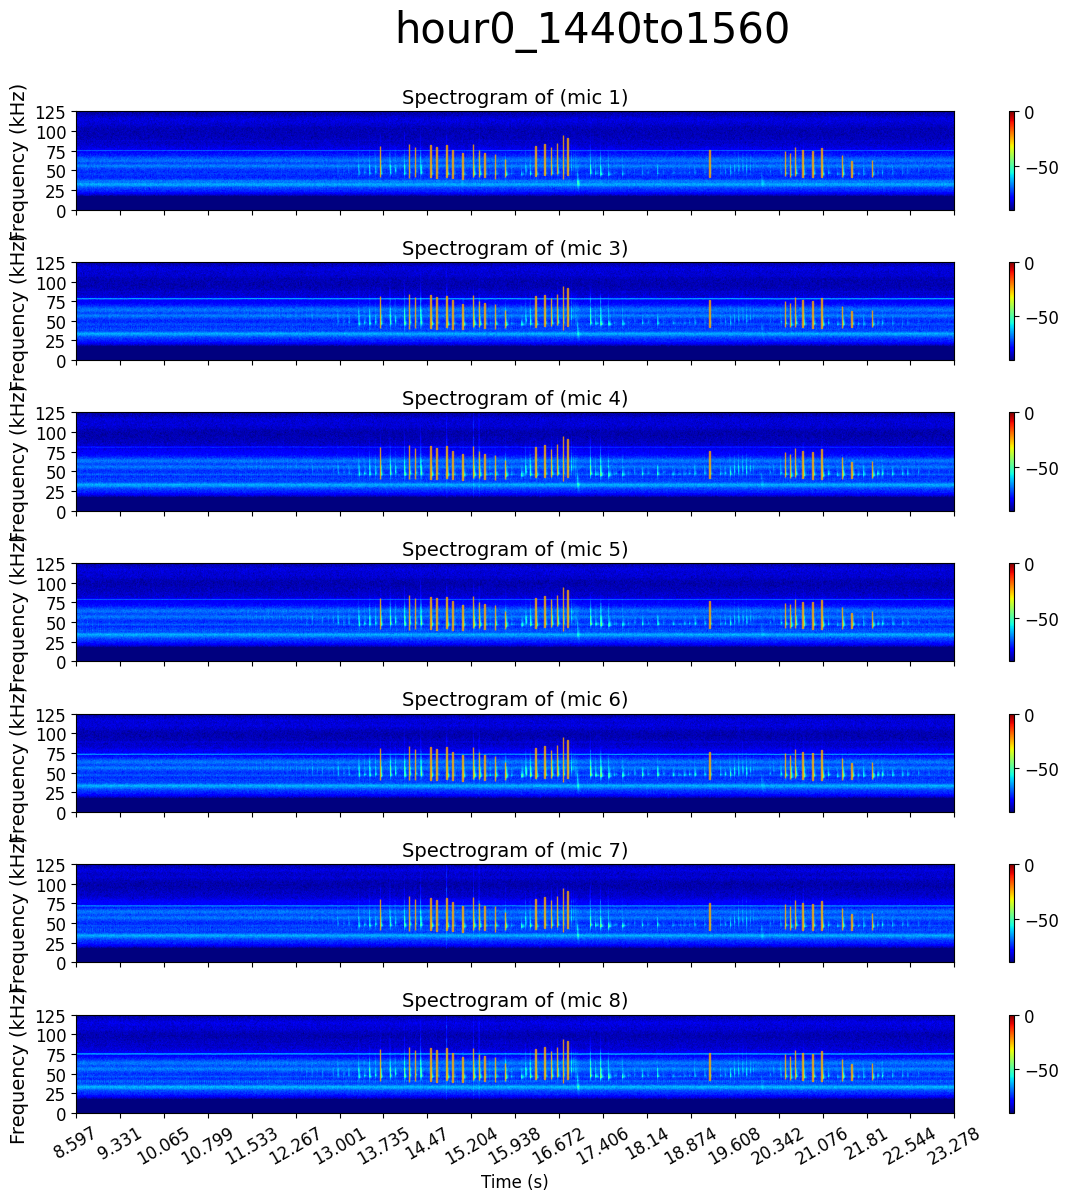

In [325]:
%matplotlib inline

channel_num = 0
plt.figure(figsize=(12, 12))
plt.suptitle(f'hour0_{int(offset)}to{int(offset+duration_in_secs)}', y=1.0, fontsize=30)
for selected_channel in (np.arange(0, num_channels, 1).astype(int)):
    if selected_channel!=1:
        write_file = write_dir / f'{filepath.stem}_channel{selected_channel}_{int(offset)}to{int(offset+duration_in_secs)}.WAV'
        
        channel_num+=1
        start = plot_dets.iloc[0]['start_time'] - offset - 0.1
        length = plot_dets.iloc[-1]['end_time'] - plot_dets.iloc[0]['start_time']+0.2
        
        recorded_audio = sf.SoundFile(write_file)
        recorded_audio.seek(int(fs*start))
        audio_seg = recorded_audio.read(int(fs*length))
        highpassed_audio_seg = highpass_audio_signal(audio_seg, fs, 20000)

        # print(f'Plotting data from {write_file}')
        vmax = 0
        vmin = -90

        audio_features = dict()
        audio_features['file_path'] = write_file
        audio_features['audio_seg'] = highpassed_audio_seg
        audio_features['sample_rate'] = fs
        audio_features['start'] = start
        audio_features['duration'] = length

        spec_features = dict()
        spec_features['NFFT'] = 512 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = vmin
        spec_features['vmax'] = vmax

        audio_features['plot_title'] = f"(mic {selected_channel+1})"
        plt.rcParams.update({'font.size': 12})
        plt.subplot(7, 1, channel_num)
        plt.title(f"Spectrogram of {audio_features['plot_title']}", fontsize=14)
        plt.specgram(highpassed_audio_seg+1e-6, NFFT=spec_features['NFFT'], cmap='jet', vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
        ax = plt.gca()
        for i, row in good_dets.iterrows():
            rect = patches.Rectangle(((row['start_time'] - offset - start)*(fs/2), row['low_freq']/(fs/2)), 
                            (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                            linewidth=1, edgecolor=FREQ_COLORS[row['KMEANS_CLASSES']], facecolor='none', alpha=0.8)
            ax.add_patch(rect)
        plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
        plot_xtype = 'float'
        if (length > 60):
            plot_xtype = 'int'
        plt.ylabel("Frequency (kHz)", fontsize=14)
        plt.colorbar()
        plt.xticks(ticks=np.linspace(0, length*(fs/2), 21), labels=['']*21, rotation=30)
        plt.xlabel("")
        
plt.xticks(ticks=np.linspace(0, length*(fs/2), 21), labels=np.round(np.linspace(start, start+length, 21, dtype=plot_xtype), 3), rotation=30)
plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

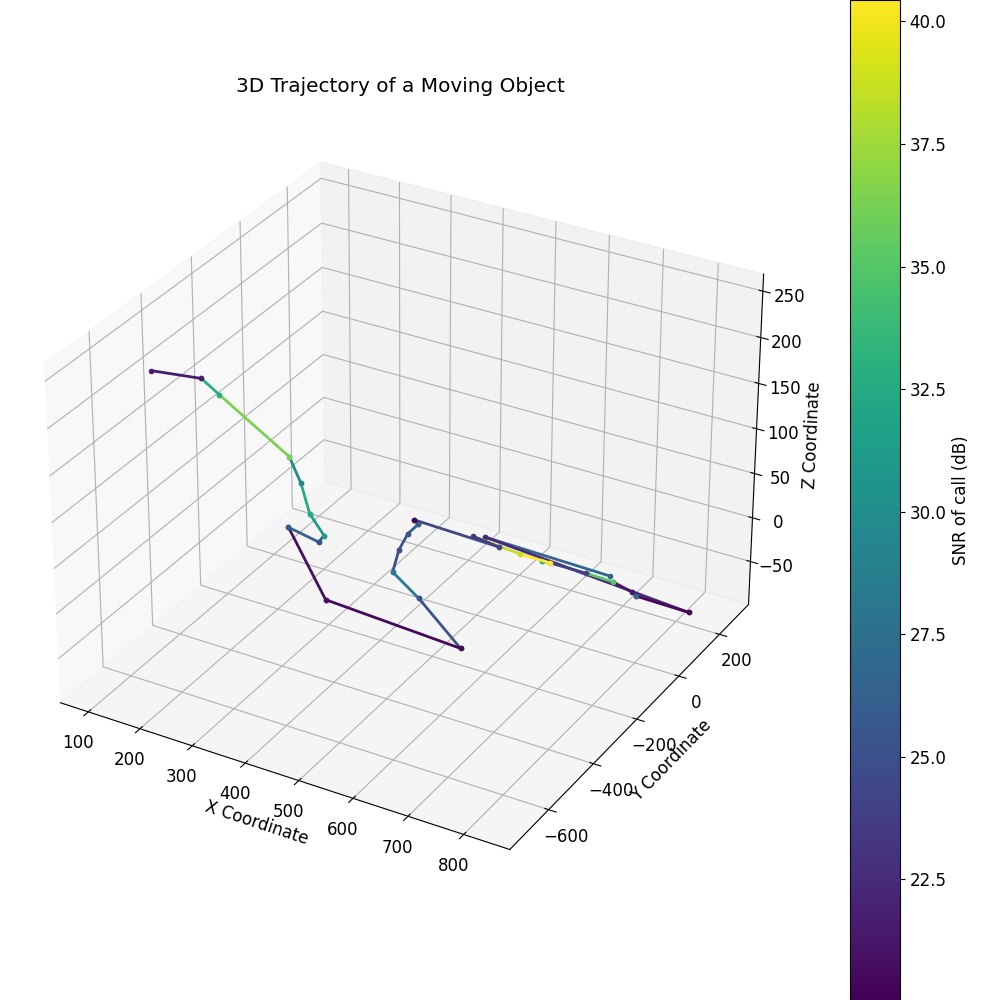

In [326]:
%matplotlib widget

import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable

# Step 1: Create a matrix of x, y, z coordinates
# Example trajectory: a sine wave in 3D space
t = good_dets['SNR']
# t = np.linspace(start, start+length, len(good_dets))

# Step 2: Set up the 3D plot
fig = plt.figure(figsize=(10, 10))
plt.rcParams.update({'font.size':12})
ax = fig.add_subplot(111, projection='3d')

# Step 3: Define colormap based on the time or index
norm = plt.Normalize(vmin=t.min(), vmax=t.max())
colors = cm.viridis(norm(t))  # Color map for time-based variation

# ax.plot(bucket[0, :], bucket[1, :], bucket[2, :], linewidth=2)  # Keep linewidth constant

# Step 4: Plot trajectory in segments with varying color
for i in range(len(t) - 1):
    ax.plot(cleaned_bucket[0, i:i+2], cleaned_bucket[1, i:i+2], cleaned_bucket[2, i:i+2], 
            color=colors[i], marker='.', linewidth=2)  # Keep linewidth constant


# Step 4: Add labels and title
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')
ax.set_title('3D Trajectory of a Moving Object')


# Step 6: Set standard axis limits
# ax.set_xlim([-250, 600])  # X-axis limits
# ax.set_ylim([0, 2000])  # Y-axis limits
# ax.set_zlim([-100, 100])  # Z-axis limits 

fig.subplots_adjust(left=0.0, right=1, bottom=0, top=1)

# Step 6: Create a ScalarMappable and add a colorbar
sm = ScalarMappable(cmap=cm.viridis, norm=norm)
sm.set_array([])  # Dummy array for colorbar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('SNR of call (dB)')

# Show the plot
plt.show()

Text(0, 0.5, 'Z-axis')

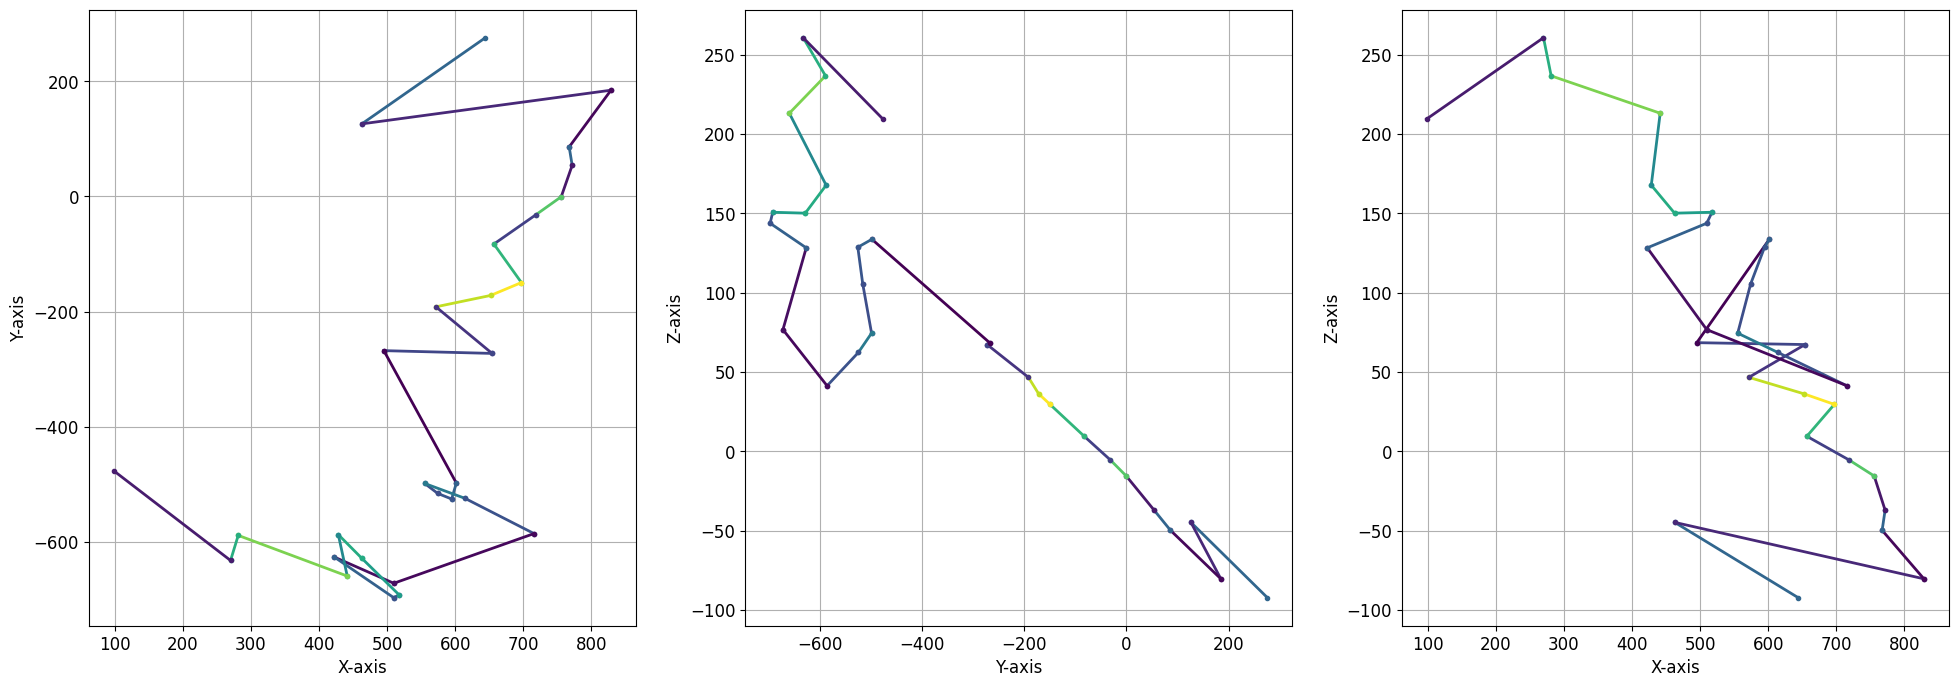

In [327]:
%matplotlib inline

fig = plt.figure(figsize=(24, 8))
plt.rcParams.update({'font.size':12})

plt.subplot(131)
# Step 3: Define colormap based on the time or index
norm = plt.Normalize(vmin=t.min(), vmax=t.max())
colors = cm.viridis(norm(t))  # Color map for time-based variation

# ax.plot(bucket[0, :], bucket[1, :], bucket[2, :], linewidth=2)  # Keep linewidth constant

# Step 4: Plot trajectory in segments with varying color
for i in range(len(t) - 1):
    plt.plot(cleaned_bucket[0, i:i+2], cleaned_bucket[1, i:i+2], 
            color=colors[i], marker='.', linewidth=2)  # Keep linewidth constant
plt.grid(which='both')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

plt.subplot(132)
# Step 3: Define colormap based on the time or index
norm = plt.Normalize(vmin=t.min(), vmax=t.max())
colors = cm.viridis(norm(t))  # Color map for time-based variation

# ax.plot(bucket[0, :], bucket[1, :], bucket[2, :], linewidth=2)  # Keep linewidth constant

# Step 4: Plot trajectory in segments with varying color
for i in range(len(t) - 1):
    plt.plot(cleaned_bucket[1, i:i+2], cleaned_bucket[2, i:i+2], 
            color=colors[i], marker='.', linewidth=2)  # Keep linewidth constant
plt.grid(which='both')
plt.xlabel('Y-axis')
plt.ylabel('Z-axis')

plt.subplot(133)
# Step 3: Define colormap based on the time or index
norm = plt.Normalize(vmin=t.min(), vmax=t.max())
colors = cm.viridis(norm(t))  # Color map for time-based variation

# ax.plot(bucket[0, :], bucket[1, :], bucket[2, :], linewidth=2)  # Keep linewidth constant

# Step 4: Plot trajectory in segments with varying color
for i in range(len(t) - 1):
    plt.plot(cleaned_bucket[0, i:i+2], cleaned_bucket[2, i:i+2], 
            color=colors[i], marker='.', linewidth=2)  # Keep linewidth constant
plt.grid(which='both')
plt.xlabel('X-axis')
plt.ylabel('Z-axis')
